# Overview and Summary for Sample 1

To recap, I already did some data analysis on this exact sample prior to the addition of the silver nanocubes. Hamza also did data analysis in that regard. These initial findings are compiled in a document Hamza wrote, in my personal progress paper, and I also have a powerpoint and poster discussing that. Recently, Hamza and Zhida dropcasted silver nanocubes onto this sample to see whether or not we could pinpoint additional/different interactions compared to the initial gold nanocube placement. The only potential drawback here is that because the gold nanocubes are still on the sample, it may be difficult to isolate which effects on resonances and enhancement are a consequence of which nanocube type. We'll just see how the data looks before making any further remarks on that. This new data is from this past semester. I was there for many of the optical measurements, so I will begin by sorting through those files. In particular, the folders I will be considering first are as follows:

1. 20240201_SpatialScan_4K_20uW
2. 20240131_SpatialScan_Sample1_RoomTemperature COMPLETE
3. 20240205_5uW_CryogenicSpatialScan_AfterAgNC

Later, I will go back through the PL and AFM data from when the sample only contained gold nanocubes.

4. 20230703_sample1_AFM 
5. 20230720_4K_PLFineSpatialScan 
6. 20230718_4K_PLSpatialScan

For darkfield images in either case

7. 20240131_Sample1_SilverNanocubePlacement COMPLETE
8. 20231130_Darkfield_Spectra_Sample1       COMPLETE

I will refer to this monolayer sample prior to the silver nanocube placement as "mAuNC" and after as "mAgNC". I will categorize in this manner

Temperature
   - Room Temperature Measurements 
   - Cryogenic Measurements
   
Optical
   - PL
   - Darkfield
   
Physical
   - AFM

# Imports

In [1]:
!pip install sif_parser

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sif_parser
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Comparing Darkfield Images

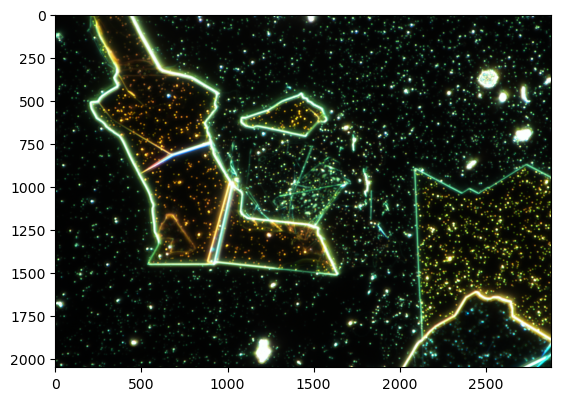

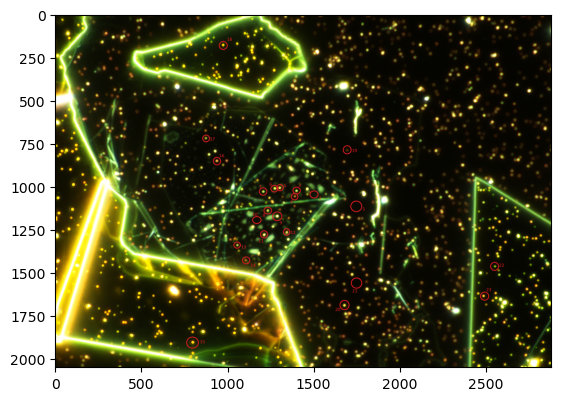

In [3]:
with open('50ms_x50_DF.png', 'rb') as f:
    image_data = f.read()
image_path = '50ms_x50_DF.png'
image = mpimg.imread(image_path)
x = np.arange(image.shape[1] + 1)
y = np.arange(image.shape[0] + 1)
plt.imshow(image, cmap='gray')
plt.show()

with open('DarkField_Marked.png', 'rb') as f:
    image_data = f.read()
image_path = 'DarkField_Marked.png'
image = mpimg.imread(image_path)
x = np.arange(image.shape[1] + 1)
y = np.arange(image.shape[0] + 1)
plt.imshow(image, cmap='gray')
plt.show()

These are unmarked and marked images of mAuNC.

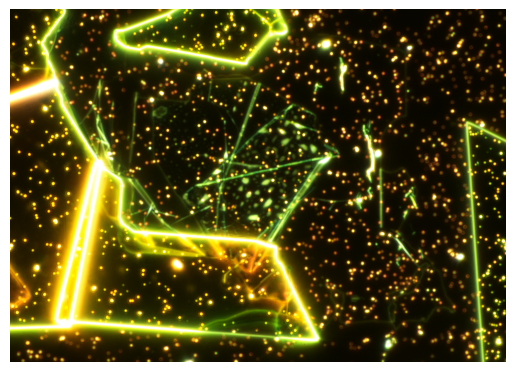

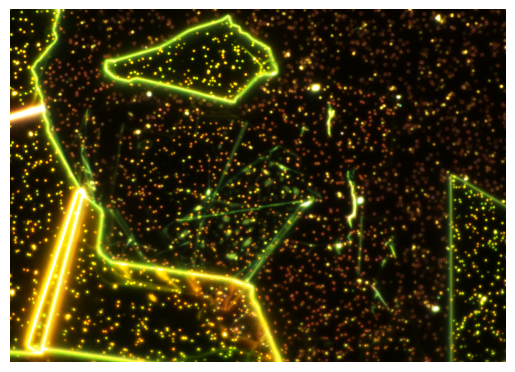

In [7]:
with open('DF.png', 'rb') as f:
    image_data = f.read()
image_path = 'DF.png'
image = mpimg.imread(image_path)
#plt.subplot(1, 2, 1)  # Create subplot at position 1 in a 1x2 grid
plt.imshow(image)
plt.axis('off')

plt.show()

with open('DF (1).png', 'rb') as f:
    image_data = f.read()
image_path = 'DF (1).png'
image = mpimg.imread(image_path)
#plt.subplot(1, 2, 2)  # Create subplot at position 2 in a 1x2 grid
plt.imshow(image)
plt.axis('off')

plt.show()

The left displays mAuNC and the right displays mAgNC.

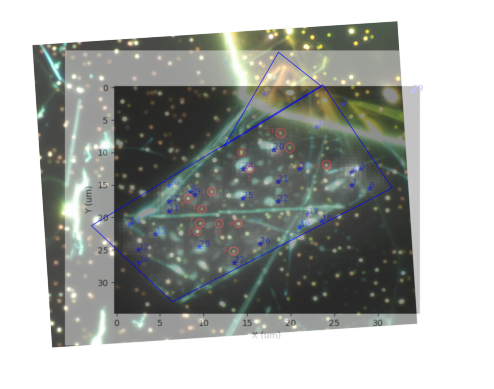

In [5]:
with open('overlay_drawing.png', 'rb') as f:
    image_data = f.read()
image_path = 'overlay_drawing.png'
image = mpimg.imread(image_path)
plt.imshow(image)
plt.axis('off') 
plt.show()

In [14]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px
import xarray as xr
from skimage.feature import blob_dog, blob_log, blob_doh
from scipy import ndimage
import plotly.graph_objects as go

In [8]:
def hyperspectral_spatial_image(title,folder,calibration_file,xsteps,ysteps,x_step_size,y_step_size,rel_spec_ind,x_crop,y_crop):
    
    # Find and sort all files by number:
    files = [file for file in folder.glob(file_prefix+'*')] # find all relevant files
    files = sorted(files,
                   key=lambda x:float(x.name.replace(file_prefix,'').replace(file_suffix,''))) # sort files by index number

    # Calculate wl from calibration file
    wl = 1240/np.loadtxt(folder/calibration_file)[:,0]
    display(wl)

    # Load all data files into single array
    data_vector = [np.loadtxt(file) for file in files]

    # Rearrange data into spatial map according to preset xsteps and ysteps
    data = np.array(data_vector)
    data=data.reshape(xsteps,ysteps,-1)
    data = data[x_crop[0]: x_crop[1], y_crop[0]:y_crop[1]]
    x_um = np.arange(data.shape[0])*x_step_size
    y_um = np.arange(data.shape[1])*y_step_size

    int_data = data[:,:,rel_spec_ind[0]:rel_spec_ind[1]].sum(axis=2)
    plt.pcolor(int_data,cmap='gray')
    plt.colorbar() 

    # Create Data array in order to define axes 
    data_ds = xr.DataArray(
        data=data,
        coords=dict(

            x=x_um,

            y=y_um,

            wl=wl.round(1),
        ),
        )

    return wl,data_ds,x_um,y_um,data

In [9]:
def find_peaks(rel_spec_ind,data):
    fig, ax = plt.subplots(1,2)
    rel_data = data[:,:,rel_spec_ind[0]:rel_spec_ind[1]]
    rel_data = ndimage.gaussian_filter(rel_data, sigma=[0.01,0.01,10])

    pts = []

    for i in range(rel_data.shape[2]):
        if np.mod(i,10)==0:
            im = rel_data[:,:, i]
            blobs_doh = blob_dog(im, max_sigma=1, threshold_rel=0.5)
            plt.subplot(1,2,1)
            plt.imshow(im)
            plt.subplot(1,2,2)
            plt.imshow(im)
            for blob in blobs_doh:
                y, x, r = blob
                c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
                plt.gca().add_patch(c)
                pts.append([y,x])

            plt.title(wl[rel_spec_ind[0]:rel_spec_ind[1]][i].round(2))
            plt.show()

    unique_pts = np.unique((np.array(pts)).round(), axis=0)
    plt.imshow(data[:,:,rel_spec_ind[0]:rel_spec_ind[1]].sum(axis=2))
    plt.gca().invert_yaxis()
    plt.scatter(unique_pts[:,1],unique_pts[:,0],marker='*',c='r')

    background_spectra = rel_data.sum(axis=0).sum(axis=0)
    # remove peak spectra
    for pt in unique_pts.round().astype(int):
        background_spectra-= rel_data[pt[0], pt[1]]
    # normalize background
    n_points = rel_data.shape[0]*rel_data.shape[1] - len(unique_pts)
    background_spectra /= n_points

    from scipy.cluster.hierarchy import fclusterdata
    cluster_pred = fclusterdata(unique_pts, 1, criterion='distance')
    
    return unique_pts,cluster_pred,background_spectra

In [10]:
def to_codebook(X, part):
    """
    Calculates centroids according to flat cluster assignment

    Parameters
    ----------
    X : array, (n, d)
        The n original observations with d features

    part : array, (n)
        Partition vector. p[n]=c is the cluster assigned to observation n

    Returns
    -------
    codebook : array, (k, d)
        Returns a k x d codebook with k centroids
    """
    codebook = []

    for i in range(part.min(), part.max()+1):
        codebook.append(X[part == i].mean(0))

    return np.vstack(codebook)

In [11]:
def label_points(unique_pts,y_um,x_um,rel_spec_ind,title):
    unique_centroids = to_codebook(unique_pts,cluster_pred).round().astype(int)
    plt.pcolor(y_um,
               x_um,
               data[:,:,rel_spec_ind[0]:rel_spec_ind[1]].sum(axis=2),
               cmap='gray'
              )
    plt.xlabel('X (um)')
    plt.ylabel('Y (um)')

    plt.scatter(unique_centroids[:,1]*x_step_size,unique_centroids[:,0]*y_step_size,marker='*',c='b')
    for i in range(len(unique_centroids)):
        plt.annotate(i+1, (unique_centroids[i,1]*x_step_size,unique_centroids[i,0]*y_step_size), c='b')

    #plt.savefig(title + 'spatial_map.png')
    return unique_centroids

In [67]:
def make_plot(unique_centroids,title,data,wl,background_spectra):

    #fig=go.Figure()

    for i, pt in enumerate(unique_centroids):
        if i == 16: 
            spectrum = data[pt[0]-2:pt[0]+2, pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0)
            wavelength = wl[rel_spec_ind[0]:rel_spec_ind[1]]
            spectrum = spectrum[:len(wavelength)]
            #wavelength = wavelength[:len(spectrum)]
            #print(f"Spectrum length: {len(spectrum)}, Wavelength length: {len(wavelength)}")
            #fig.add_trace(go.Scatter(x= wl, y =data[pt[0]-2:pt[0]+2,
                                                    #pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0),
                                    #name=i+1
                                    #'))'
            # Plot spectrum
            plt.figure()
            plt.plot(wavelength, spectrum)
            plt.xlabel('Wavelength (nm)')
            plt.ylabel('PL Intensity')
            plt.title(f'{title} {i+1}')
            plt.grid(False)
            plt.show()
            
            return plt.gca().figure, wavelength, spectrum

    #fig.add_trace(go.Scatter(x=wl[rel_spec_ind[0]:rel_spec_ind[1]], y=background_spectra, name='bkg'))
    #fig.write_html(title + 'spectra_plots.html')
    #fig.show()

array([575.73472224, 575.8213453 , 575.90799443, ..., 664.13203888,
       664.21848589, 664.30488423])

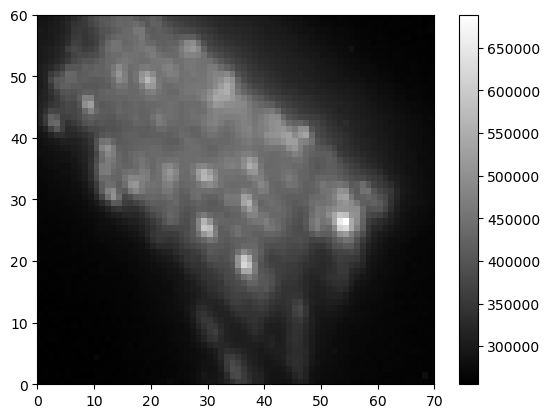

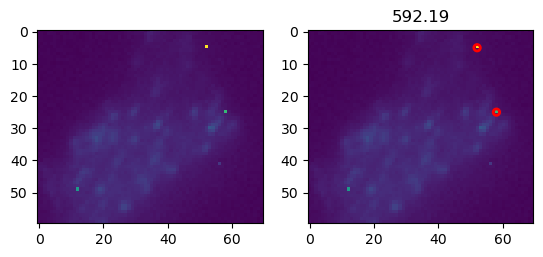

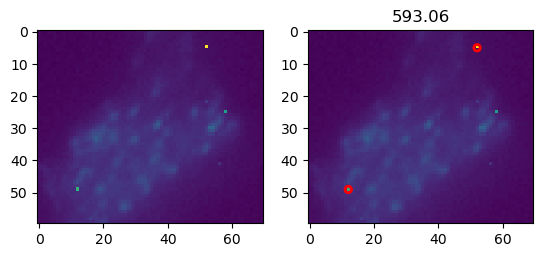

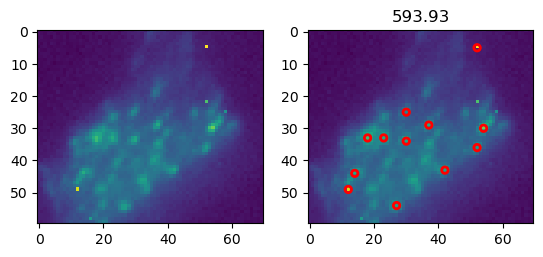

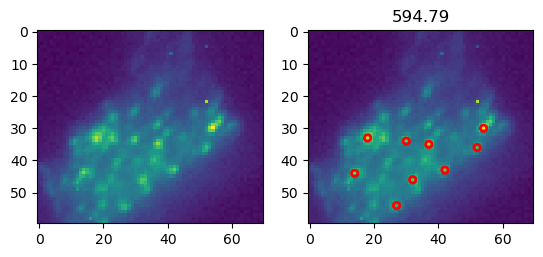

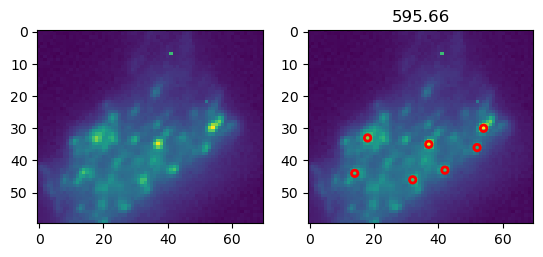

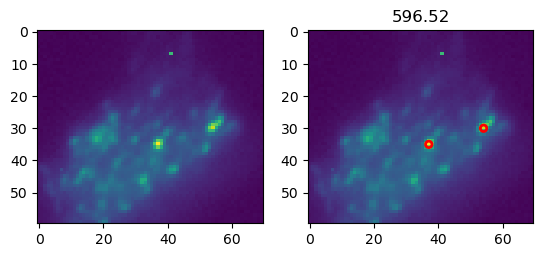

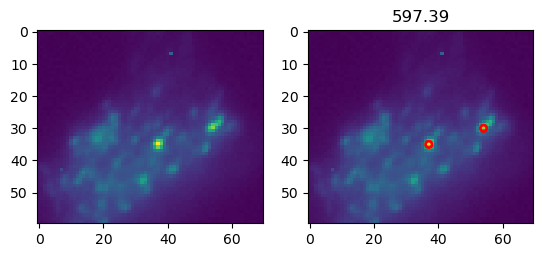

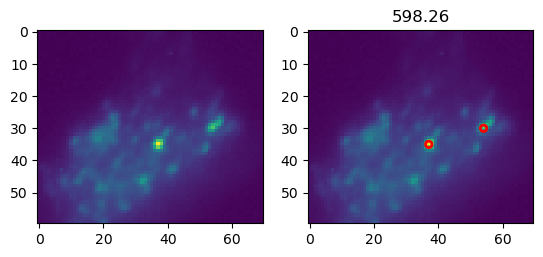

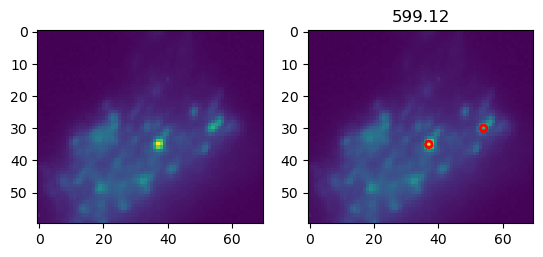

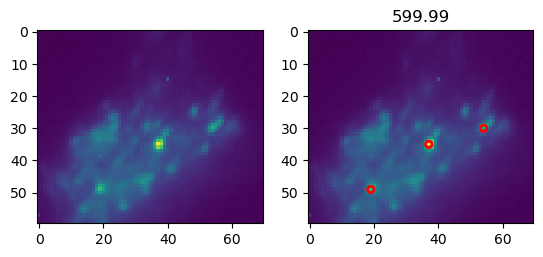

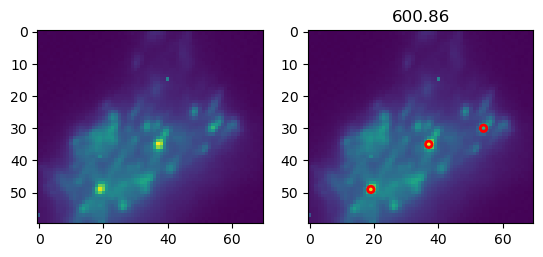

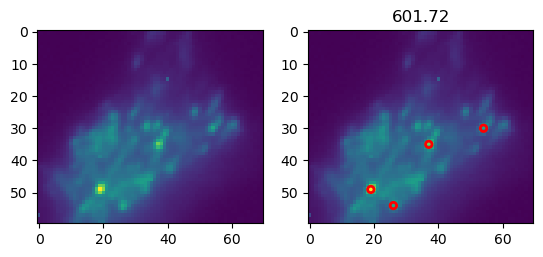

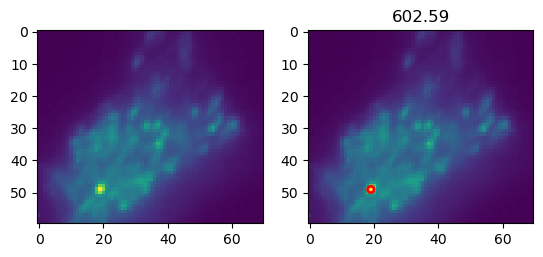

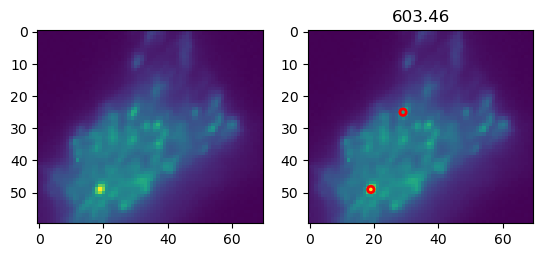

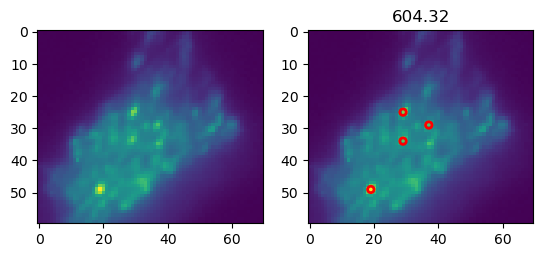

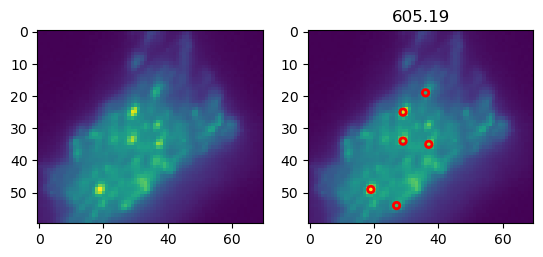

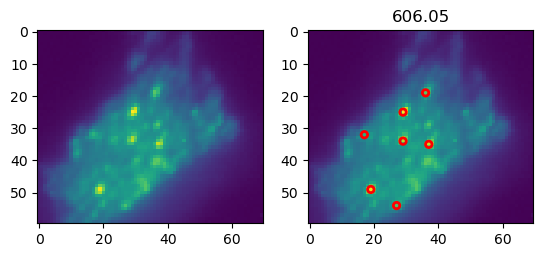

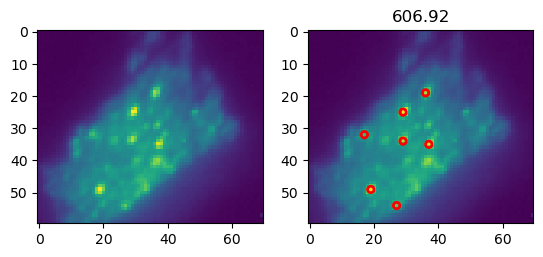

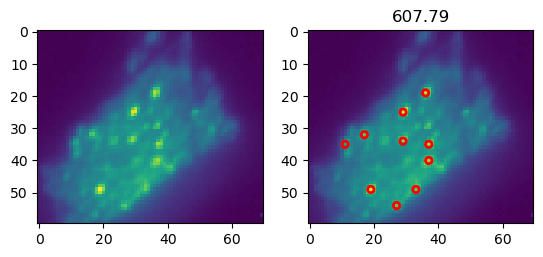

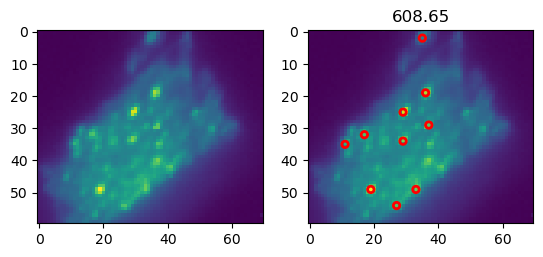

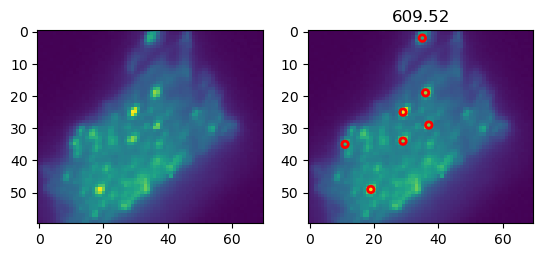

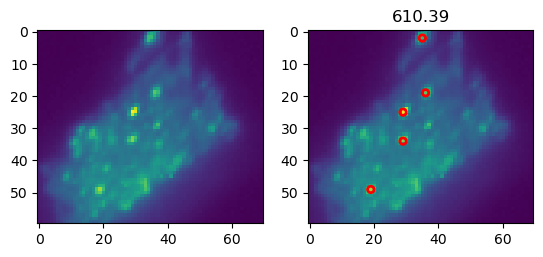

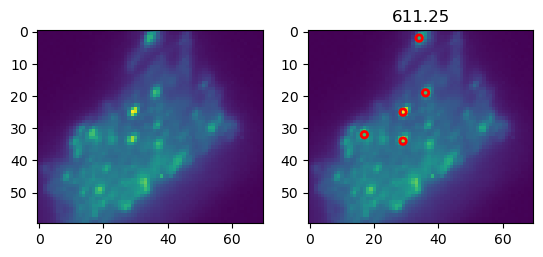

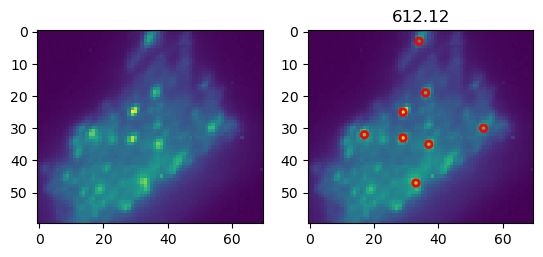

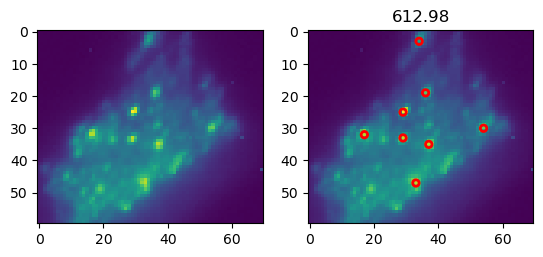

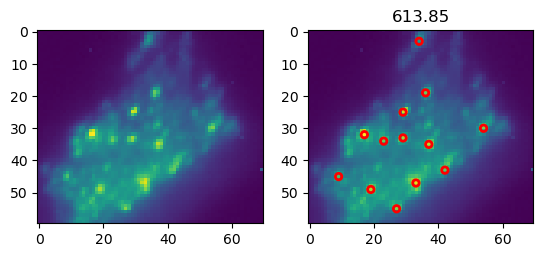

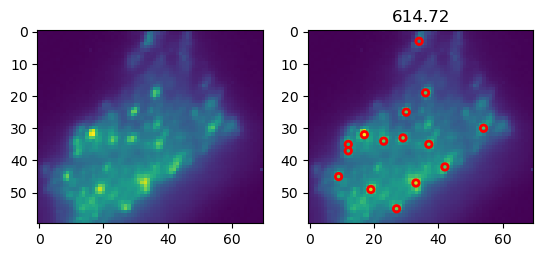

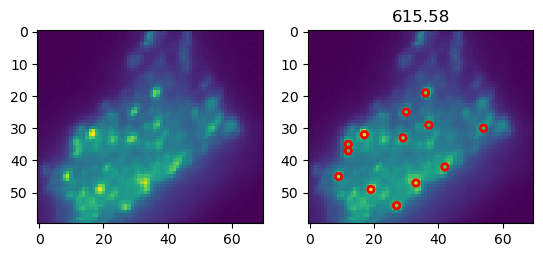

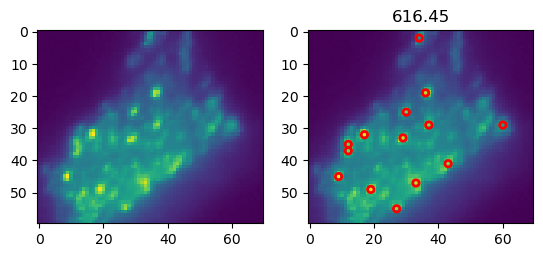

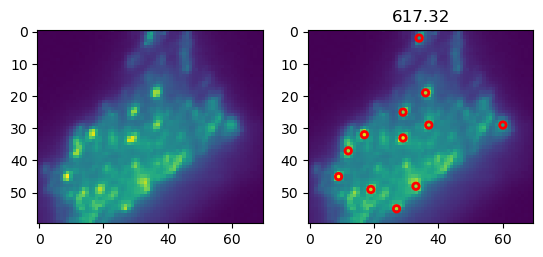

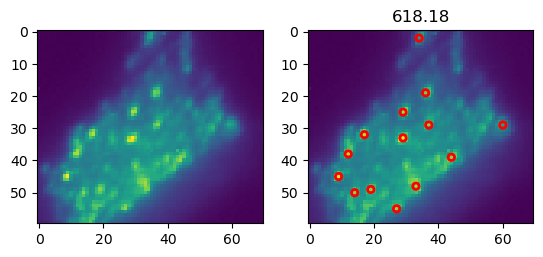

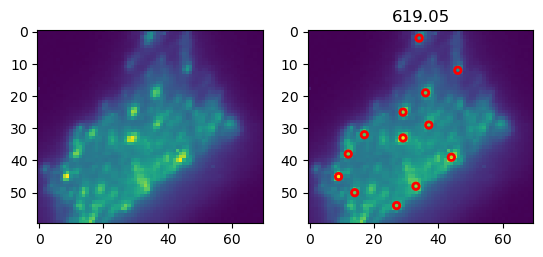

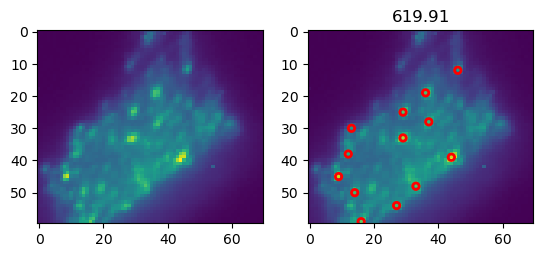

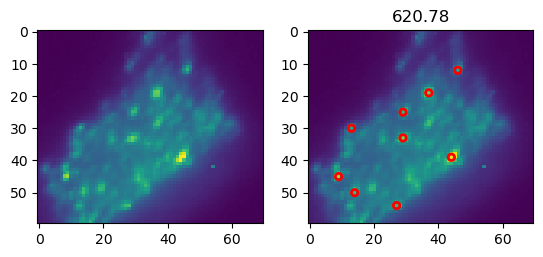

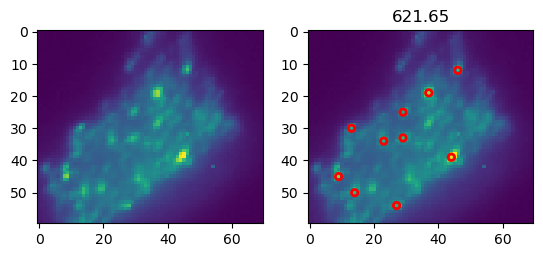

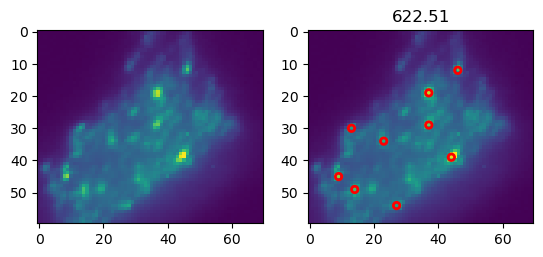

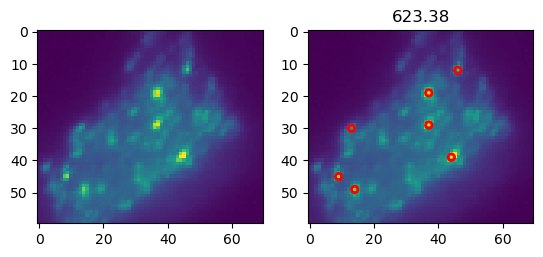

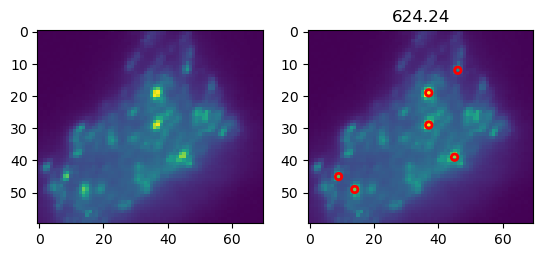

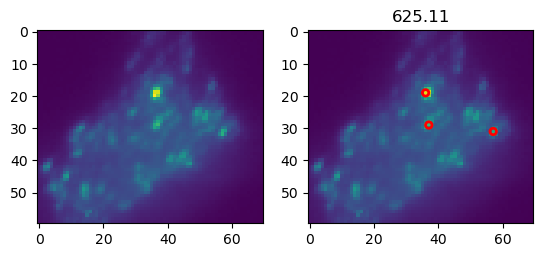

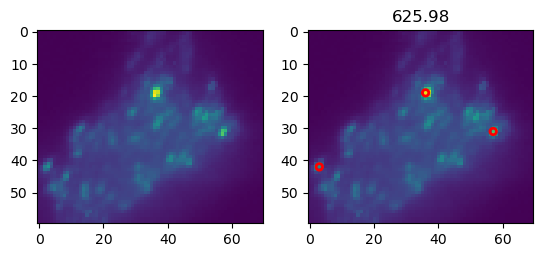

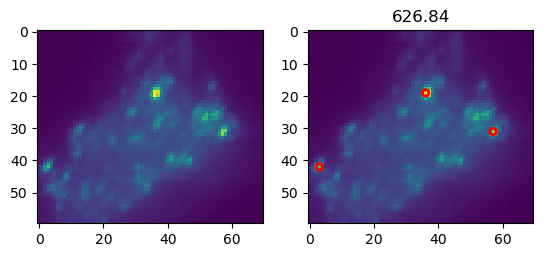

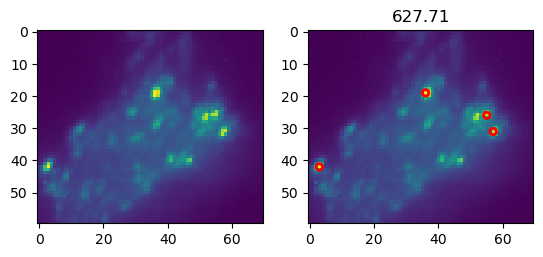

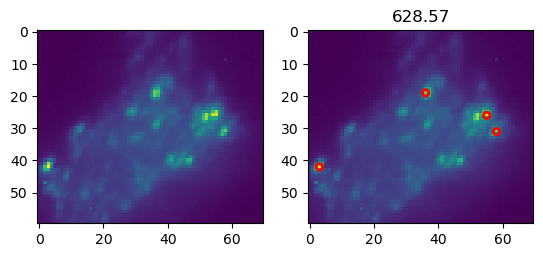

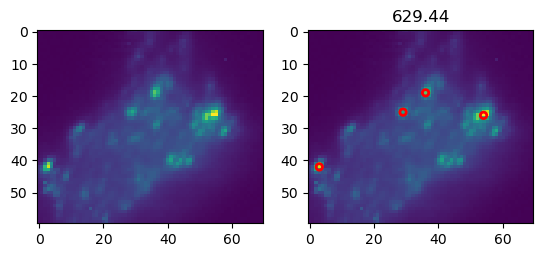

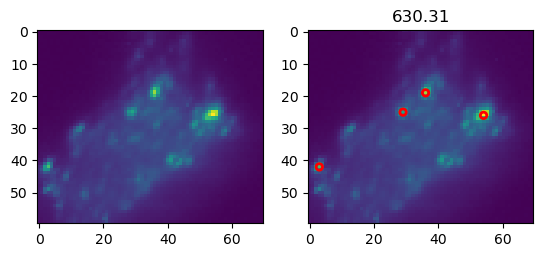

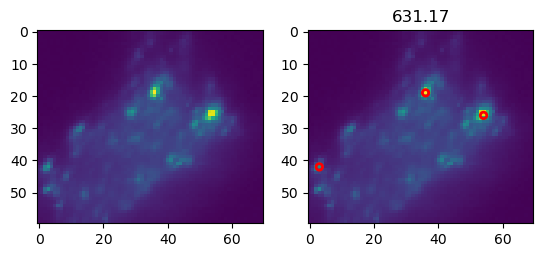

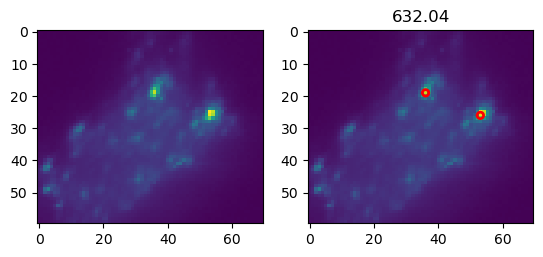

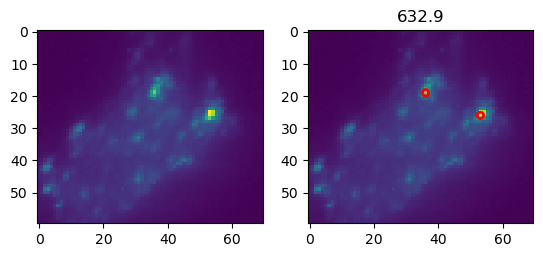

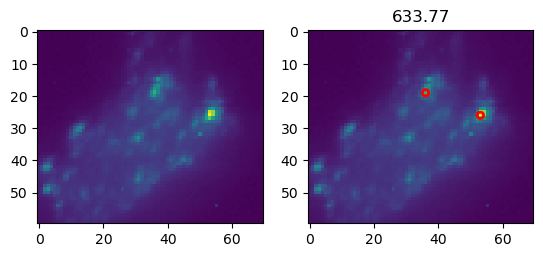

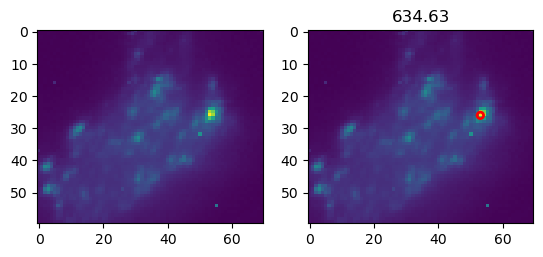

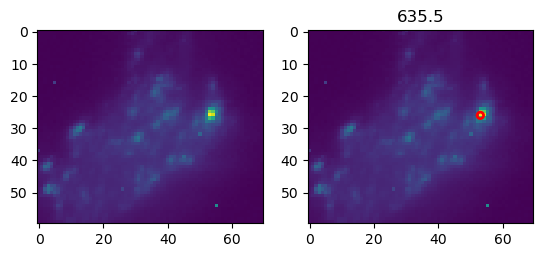

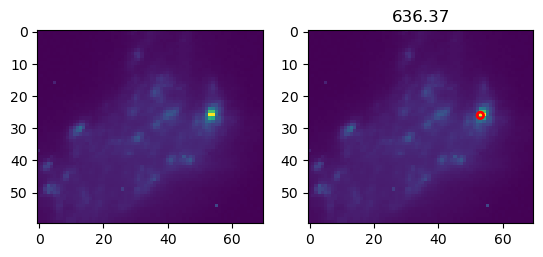

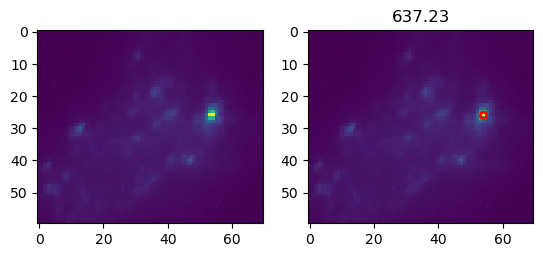

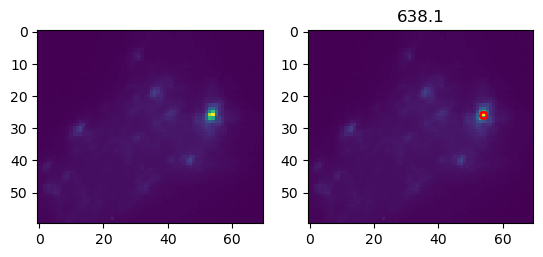

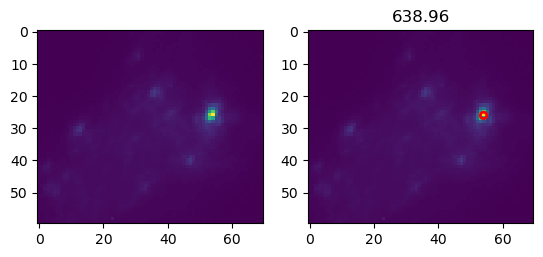

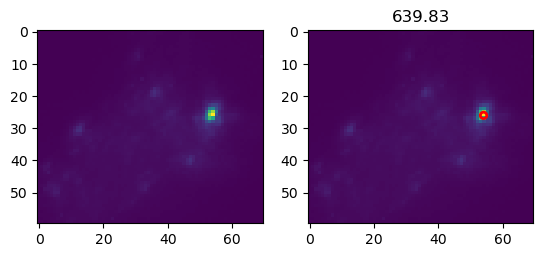

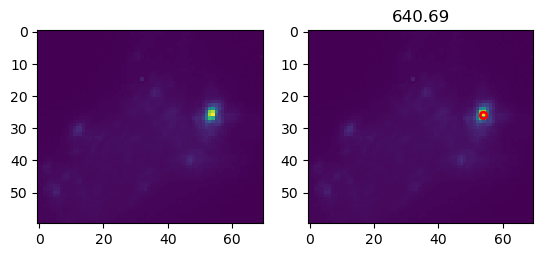

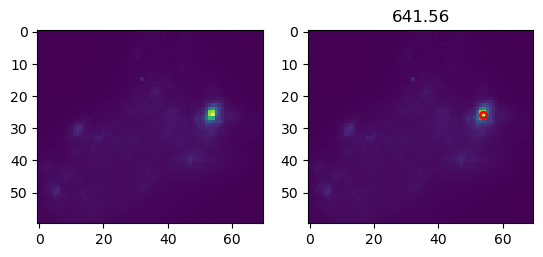

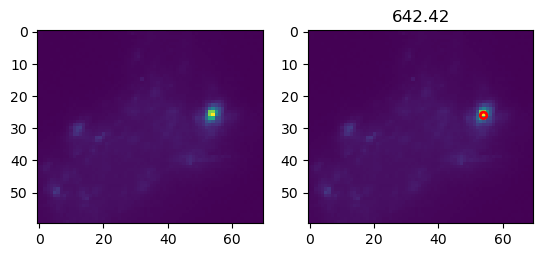

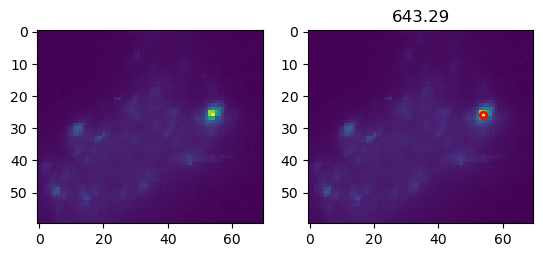

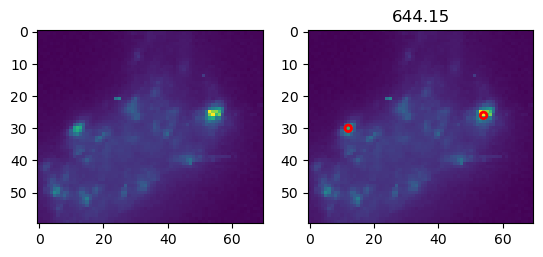

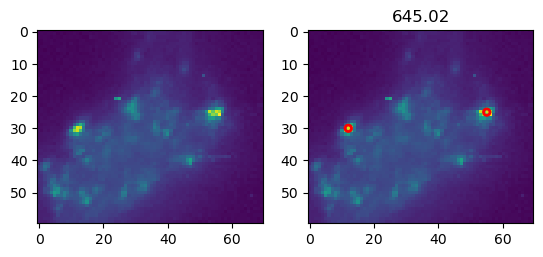

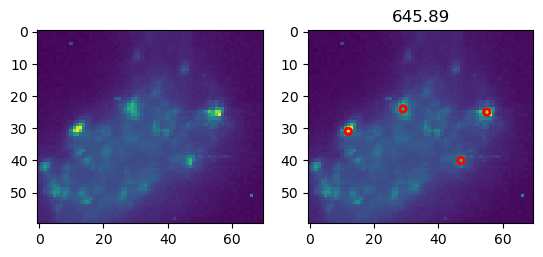

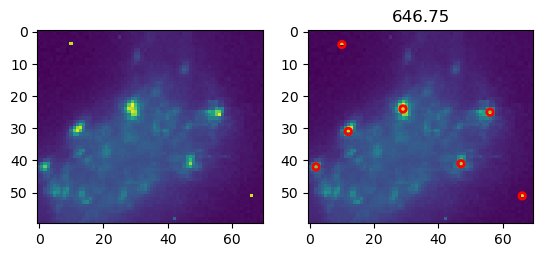

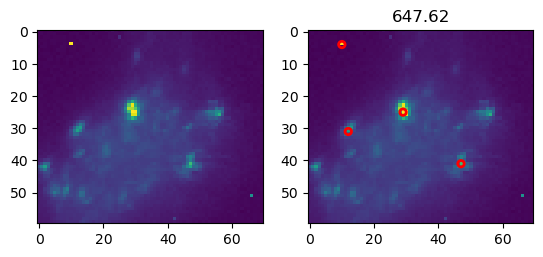

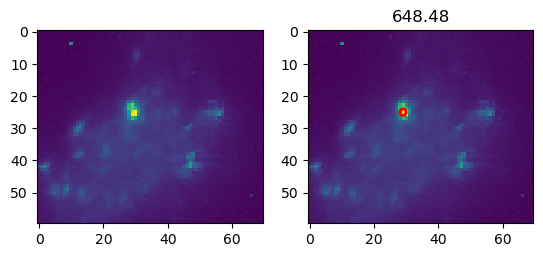

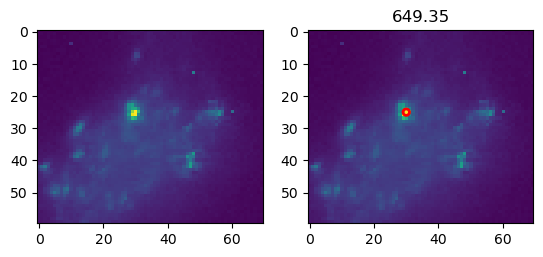

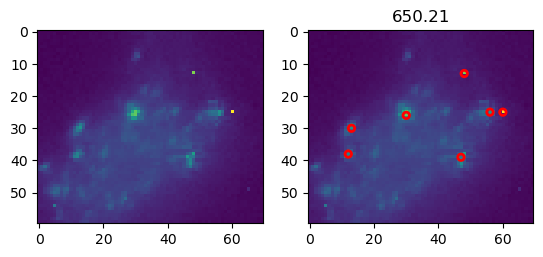

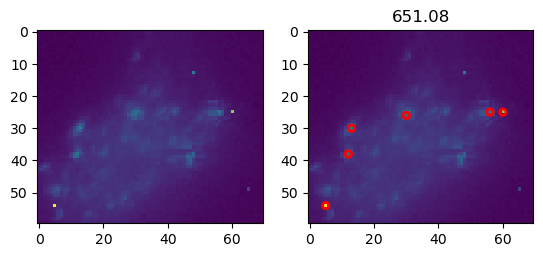

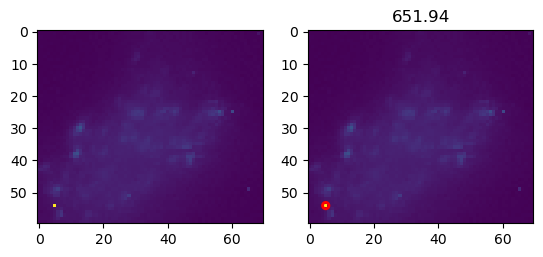

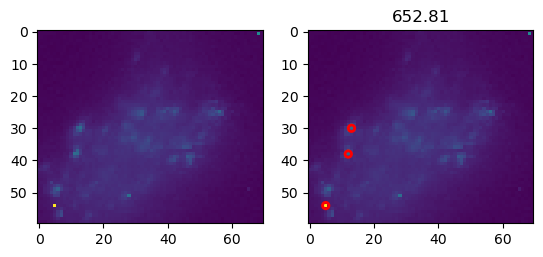

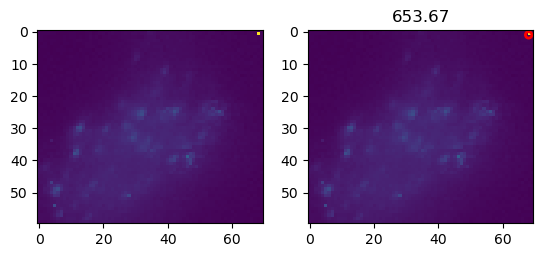

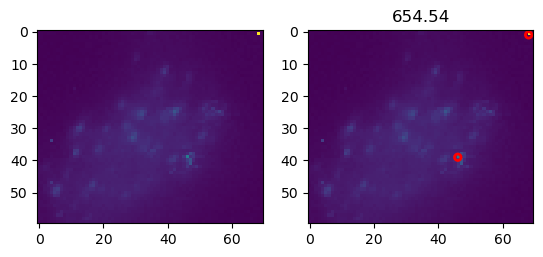

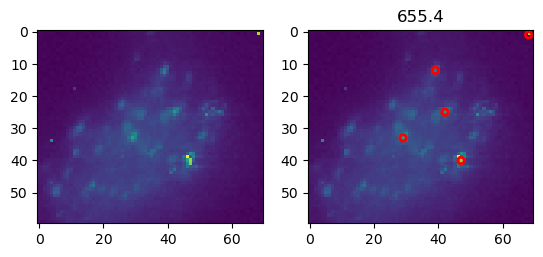

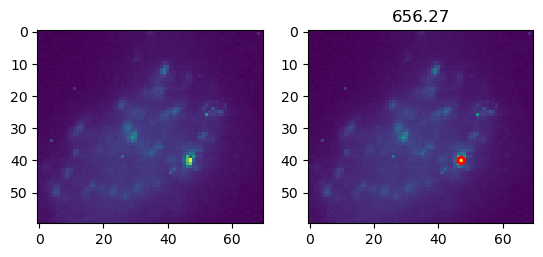

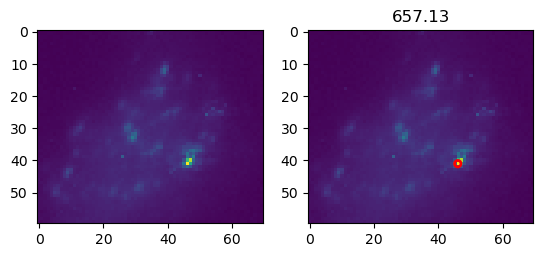

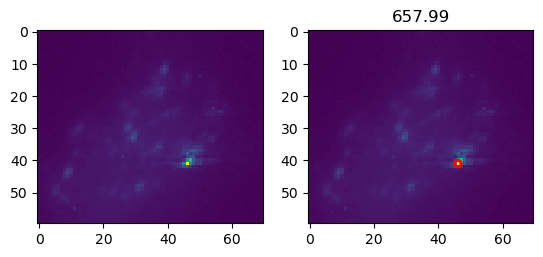

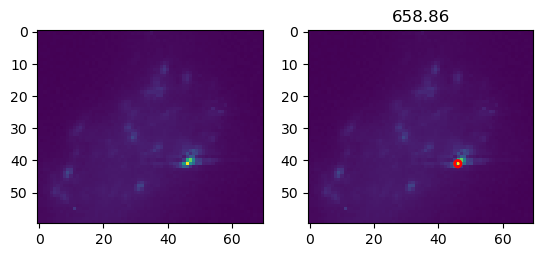

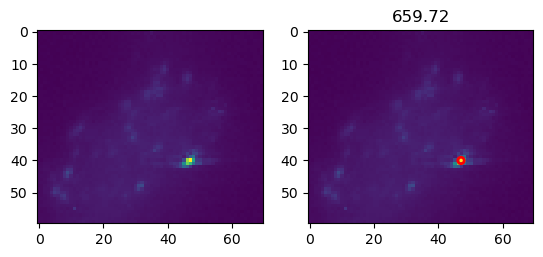

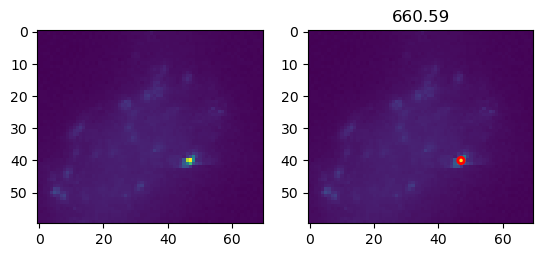

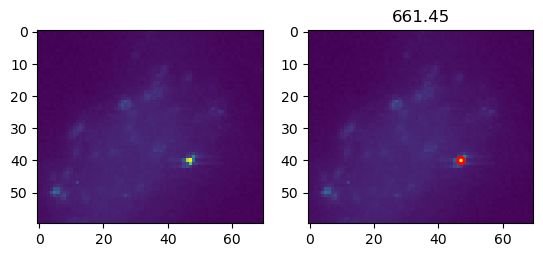

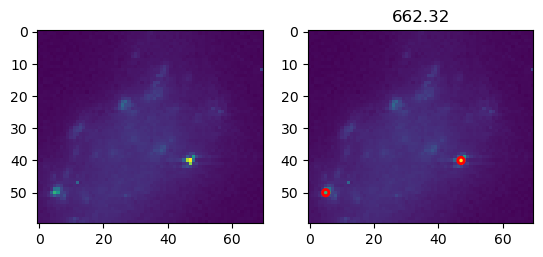

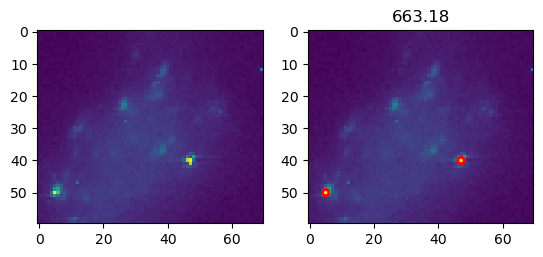

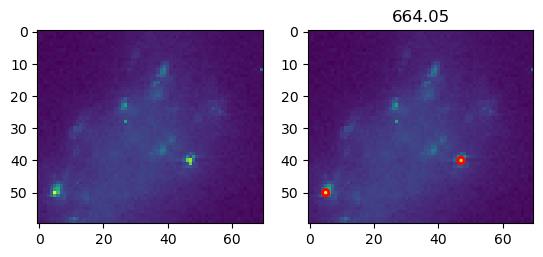

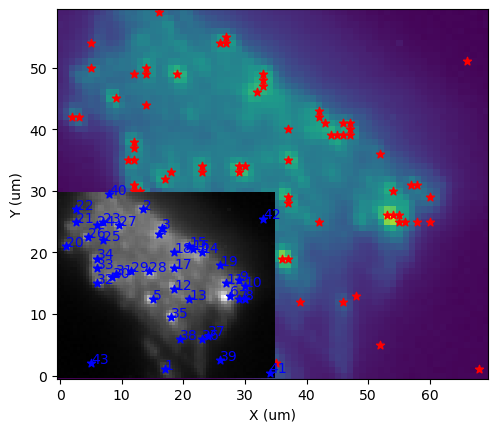

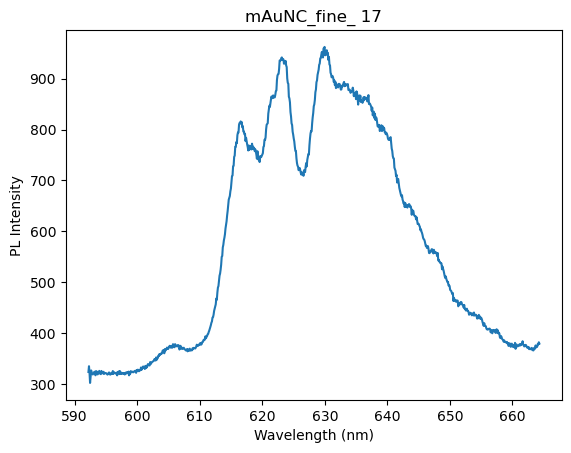

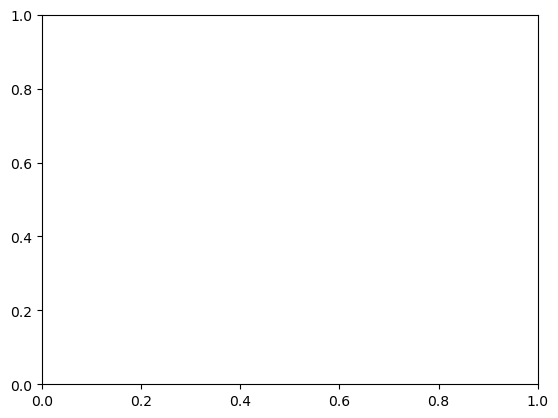

In [68]:
# Cryogenic PL mAuNC --- focus on point 17

# Define parameters
folder = Path('spatial_scan_30x30_500nmstep_600grooves_2eVcenter')
calibration_file = 'wl_calibration_2eV_600lnpmm.asc'
file_prefix = 'spatial_scan_30x30_500nmstep_600grooves_2eVcenter_'
file_suffix = '.dat'
xsteps = 70 #int(np.sqrt(len(files)))
x_step_size = 0.5 # um
ysteps = 70 #int(np.sqrt(len(files)))
y_step_size = 0.5 # um
rel_spec_ind = [190, 1024]
x_crop = [0,60]
y_crop = [0,90]
title = 'mAuNC_fine_'

wl,data_ds,x_um,y_um,data = hyperspectral_spatial_image(title,folder,calibration_file,xsteps,ysteps,x_step_size,y_step_size,rel_spec_ind,x_crop,y_crop)
unique_pts,cluster_pred,background_spectra = find_peaks(rel_spec_ind,data)
unique_centroids = label_points(unique_pts,y_um,x_um,rel_spec_ind,title)
gold_plot_initial, gpi_wavelength, gpi_spectrum = make_plot(unique_centroids,title,data,wl,background_spectra)

In [63]:
# Cryogenic PL mAgNC --- focus on point 8 and point 26

import zipfile as zf
files = zf.ZipFile("spatial_scan.zip", 'r')
files.extractall('spatial_scan')
files.close()

# Define parameters
parent_folder = Path('spatial_scan')
folder = parent_folder / 'spatial_scan'
calibration_file = '2ev_600grating_02052024.asc'
file_prefix = 'Sample1_NCWS2_2ev_5uW_80by75_500nmstep_'
file_suffix = '.dat'
xsteps = 75 #int(np.sqrt(len(files)))
x_step_size = 0.5 # um
ysteps = 80 #int(np.sqrt(len(files)))
y_step_size = 0.5 # um
rel_spec_ind = [130, -1]
x_crop = [0,50]
y_crop = [15,72]
title = 'cryo_mAgNC_'

In [64]:
def silver_plots(unique_centroids,title,data,wl,background_spectra):

    #fig=go.Figure()

    for i, pt in enumerate(unique_centroids):
        if i == 7: 
            spectrum = data[pt[0]-2:pt[0]+2, pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0)
            wavelength = wl[rel_spec_ind[0]:rel_spec_ind[1]]
            spectrum = spectrum[:len(wavelength)]
            #wavelength = wavelength[:len(spectrum)]
            #print(f"Spectrum length: {len(spectrum)}, Wavelength length: {len(wavelength)}")
            #fig.add_trace(go.Scatter(x= wl, y =data[pt[0]-2:pt[0]+2,
                                                    #pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0),
                                    #name=i+1
                                    #'))'
            # Plot spectrum
            plt.figure()
            plt.plot(wavelength, spectrum)
            plt.xlabel('Wavelength (nm)')
            plt.ylabel('PL Intensity')
            plt.title(f'{title} {i+1}')
            plt.grid(False)
            plt.show()
            
            return plt.gca().figure, wavelength, spectrum

    #fig.add_trace(go.Scatter(x=wl[rel_spec_ind[0]:rel_spec_ind[1]], y=background_spectra, name='bkg'))
    #fig.write_html(title + 'spectra_plots.html')
    #fig.show()

In [65]:
def gold_plots(unique_centroids,title,data,wl,background_spectra):

    #fig=go.Figure()

    for i, pt in enumerate(unique_centroids):
        if i == 25: 
            spectrum = data[pt[0]-2:pt[0]+2, pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0)
            wavelength = wl[rel_spec_ind[0]:rel_spec_ind[1]]
            spectrum = spectrum[:len(wavelength)]
            #wavelength = wavelength[:len(spectrum)]
            #print(f"Spectrum length: {len(spectrum)}, Wavelength length: {len(wavelength)}")
            #fig.add_trace(go.Scatter(x= wl, y =data[pt[0]-2:pt[0]+2,
                                                    #pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0),
                                    #name=i+1
                                    #'))'
            # Plot spectrum
            plt.figure()
            plt.plot(wavelength, spectrum)
            plt.xlabel('Wavelength (nm)')
            plt.ylabel('PL Intensity')
            plt.title(f'{title} {i+1}')
            plt.grid(False)
            plt.show()
            
            return plt.gca().figure, wavelength, spectrum

    #fig.add_trace(go.Scatter(x=wl[rel_spec_ind[0]:rel_spec_ind[1]], y=background_spectra, name='bkg'))
    #fig.write_html(title + 'spectra_plots.html')
    #fig.show()

array([575.73472224, 575.8213453 , 575.90799443, ..., 664.13203888,
       664.21848589, 664.30488423])

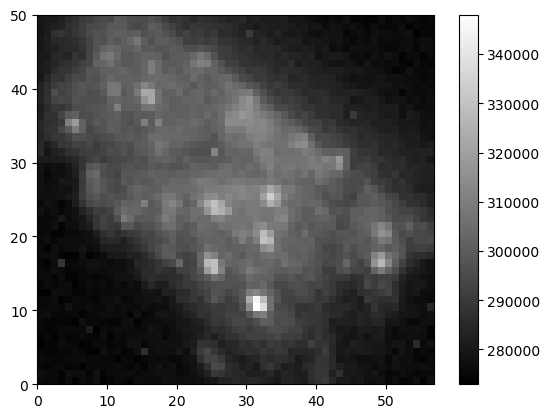

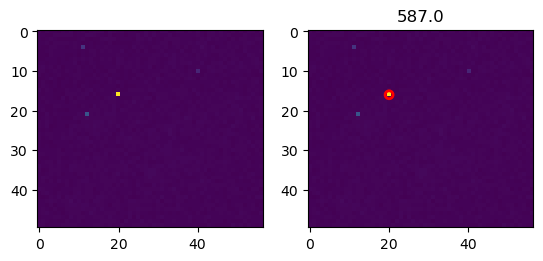

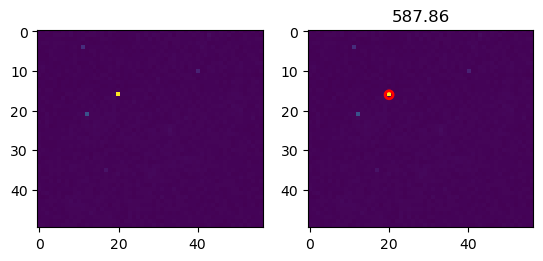

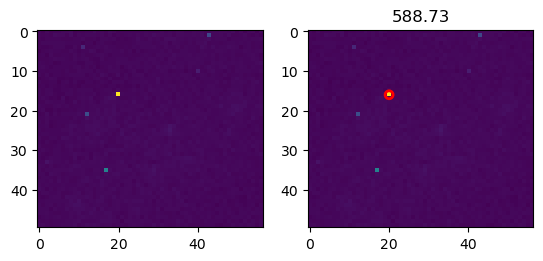

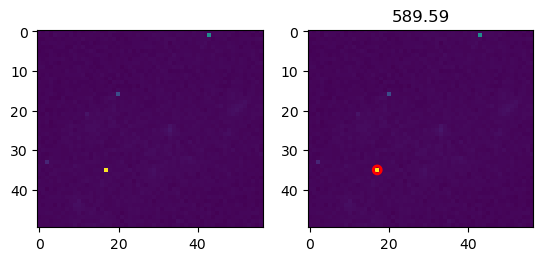

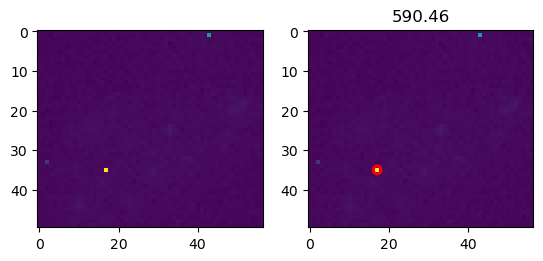

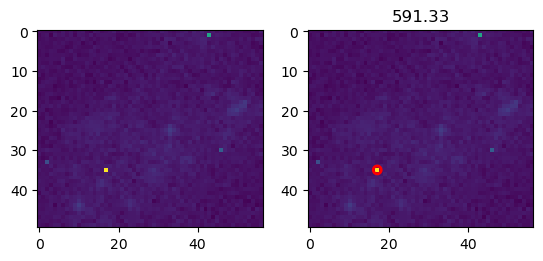

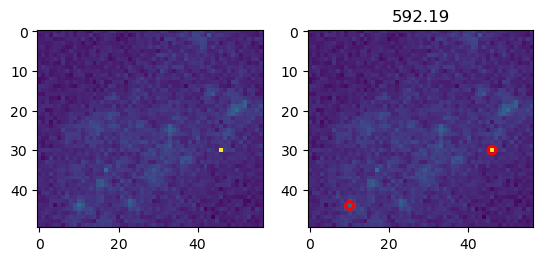

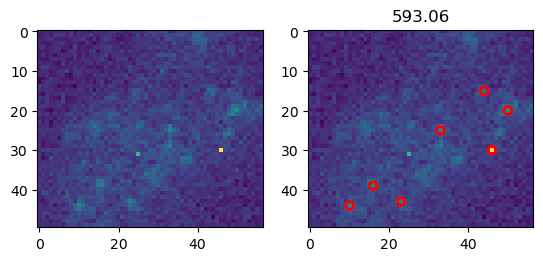

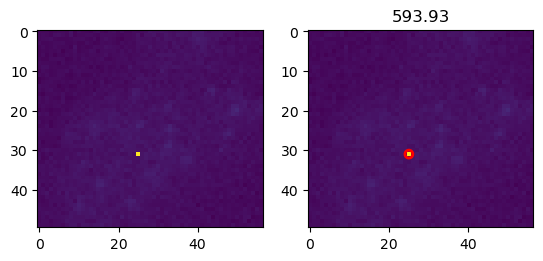

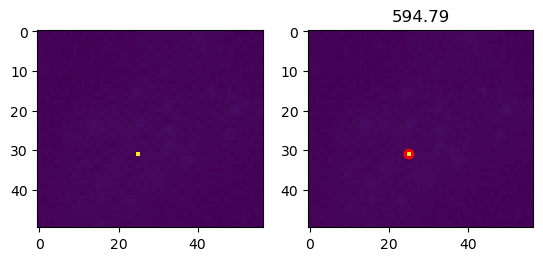

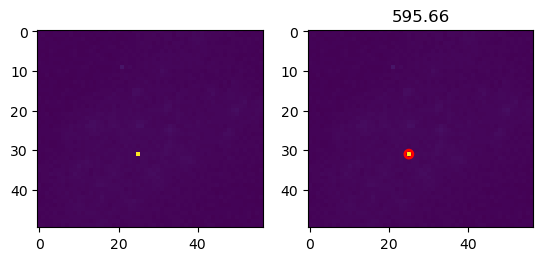

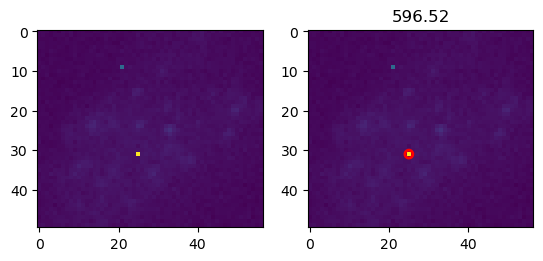

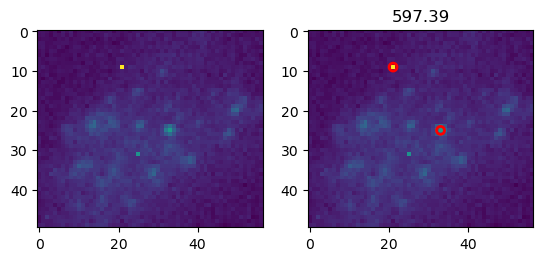

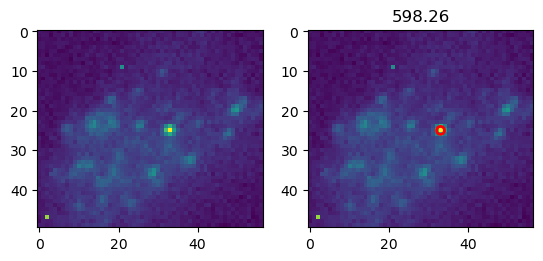

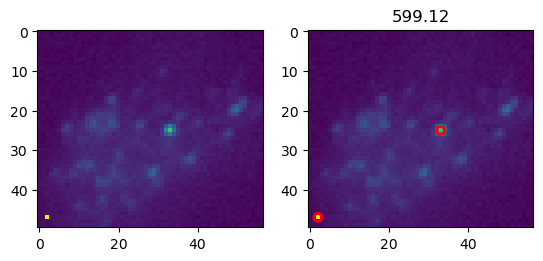

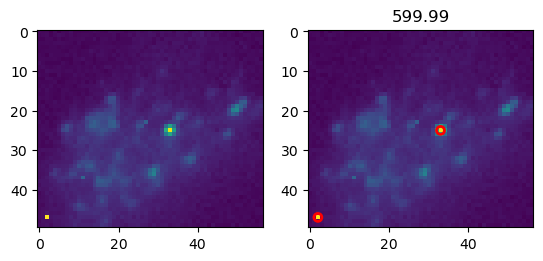

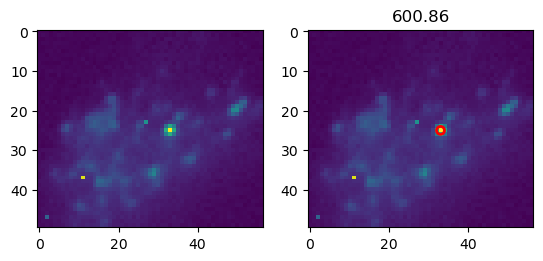

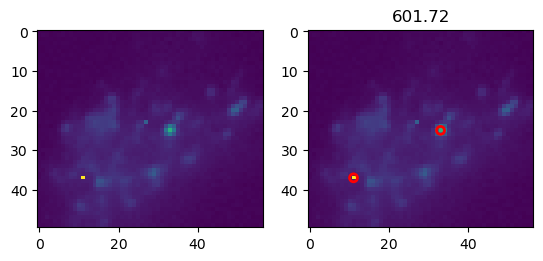

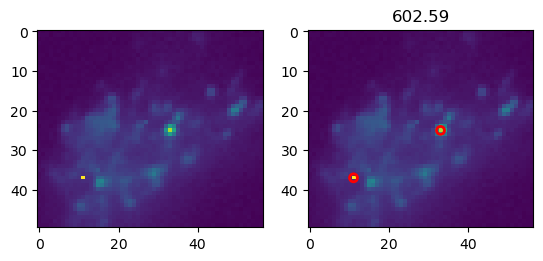

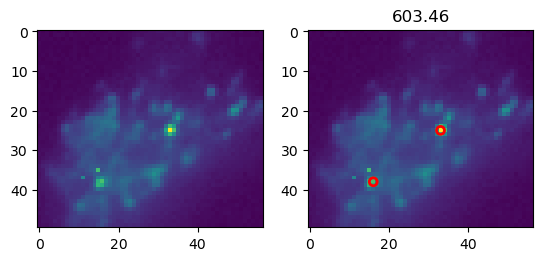

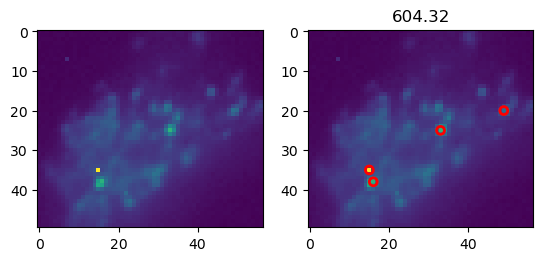

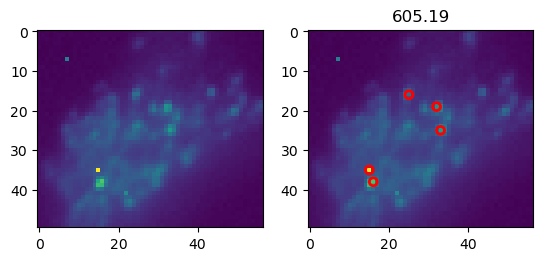

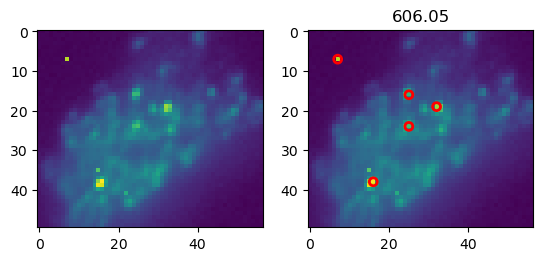

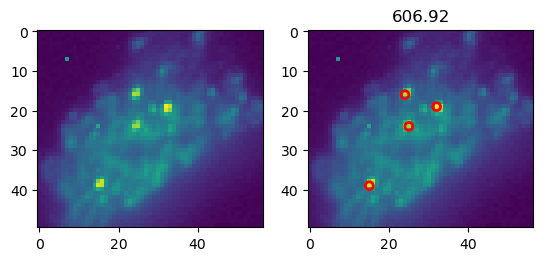

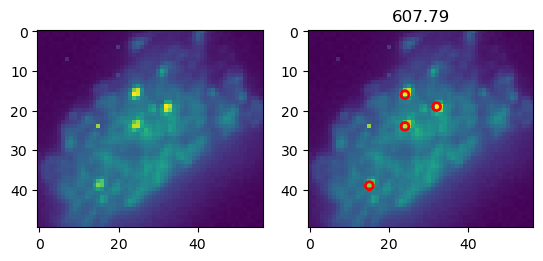

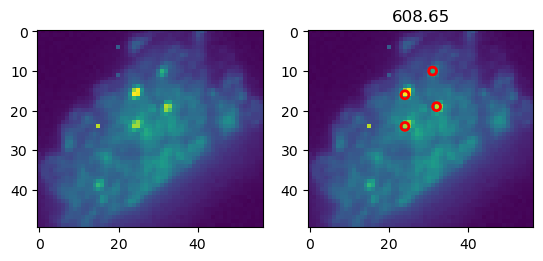

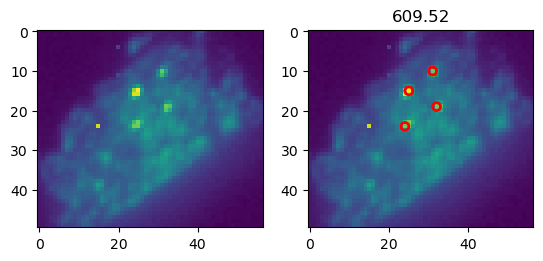

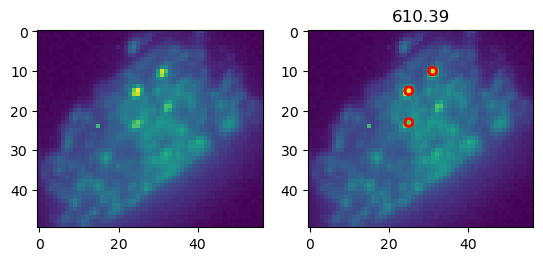

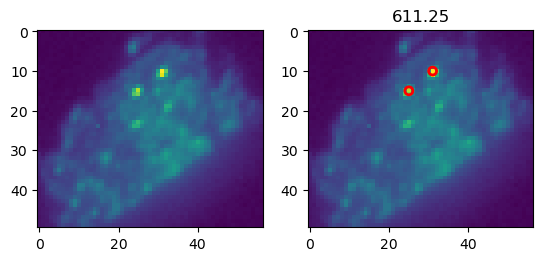

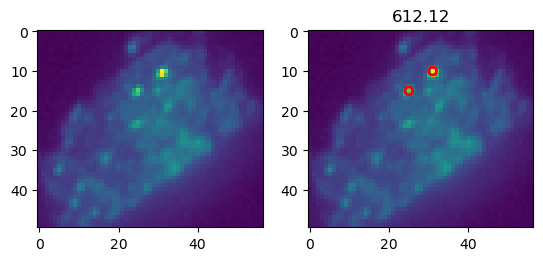

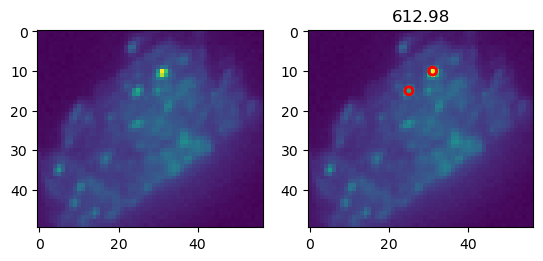

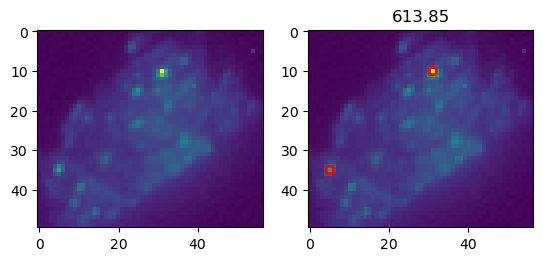

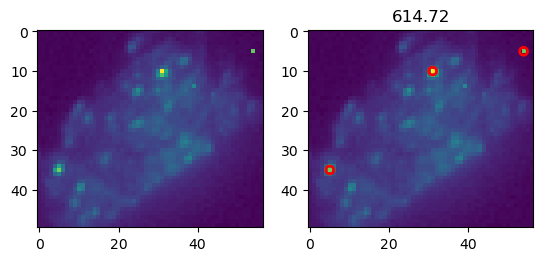

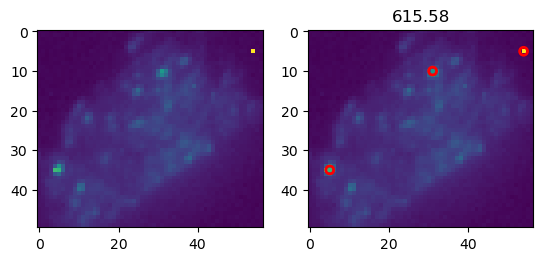

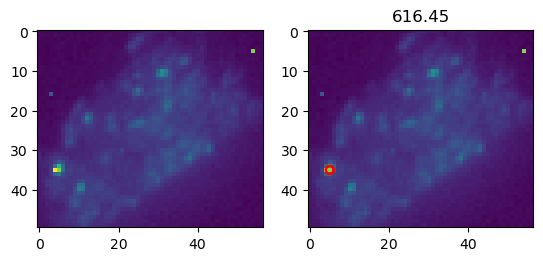

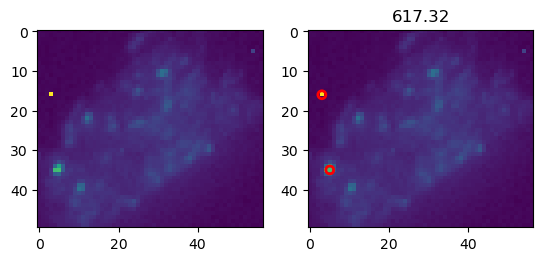

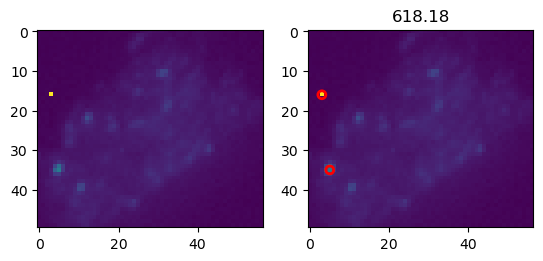

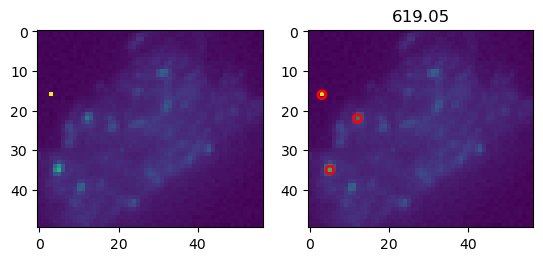

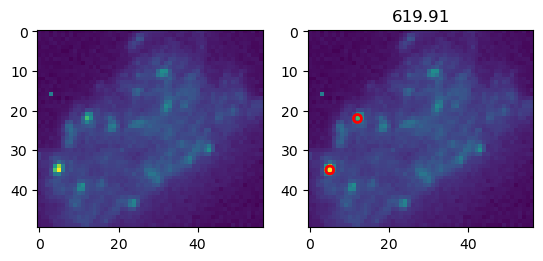

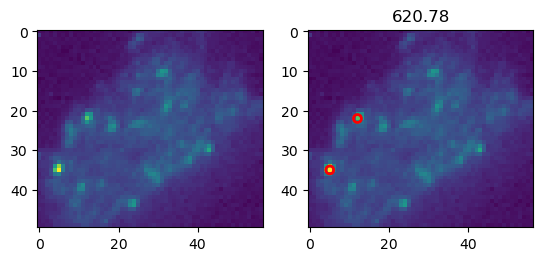

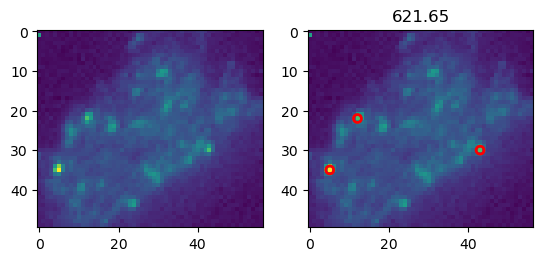

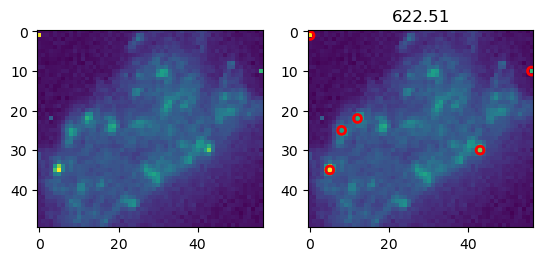

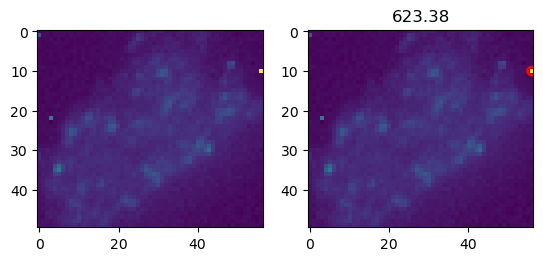

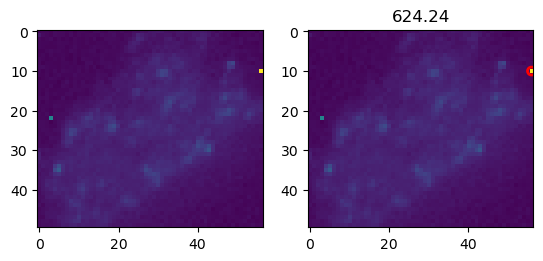

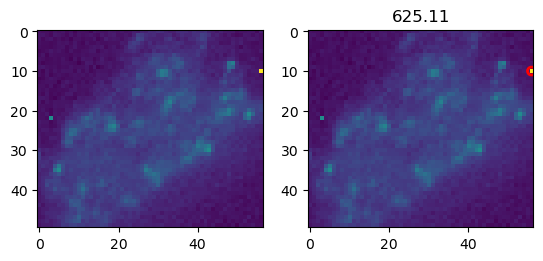

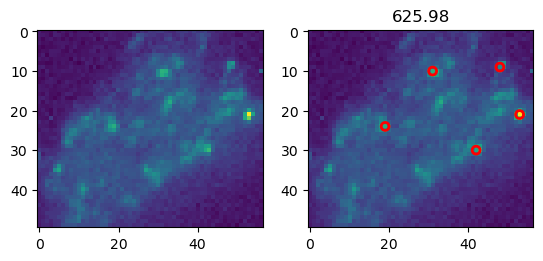

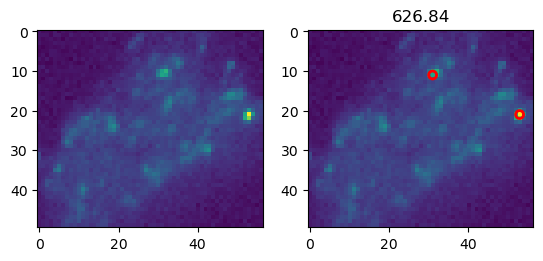

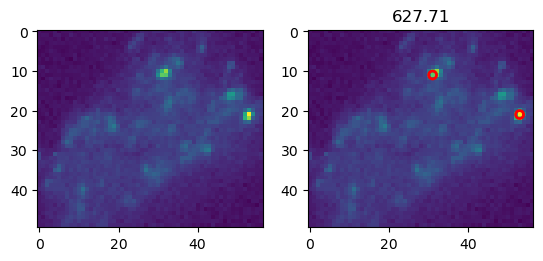

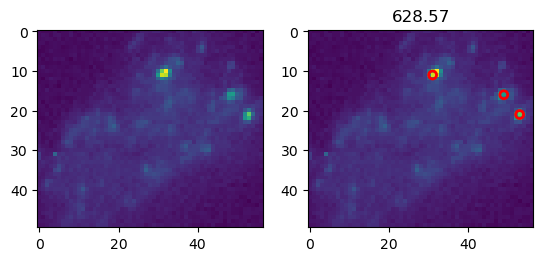

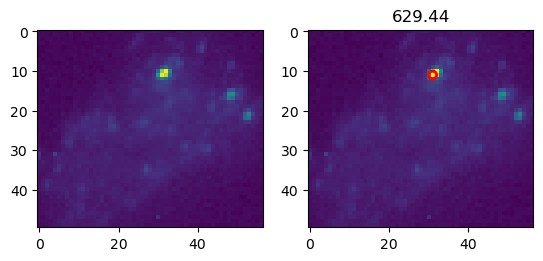

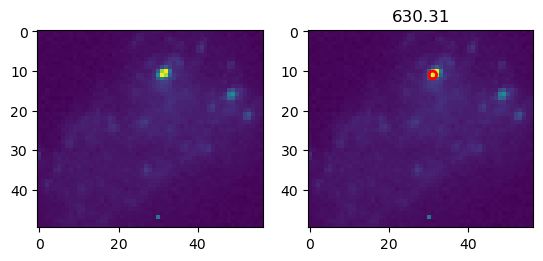

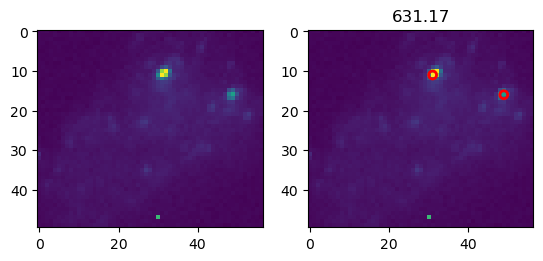

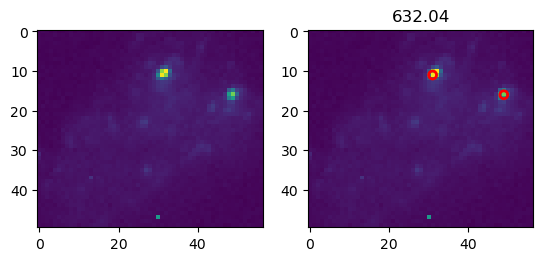

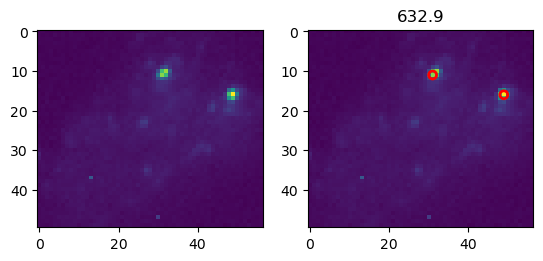

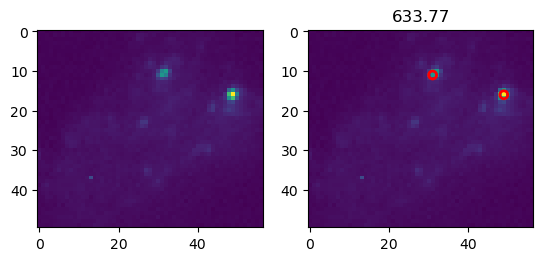

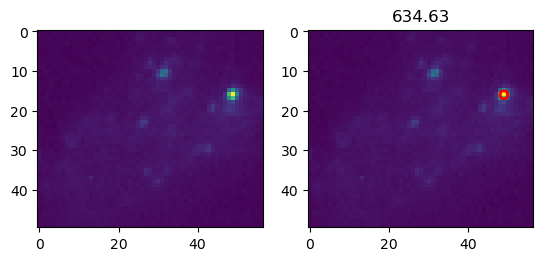

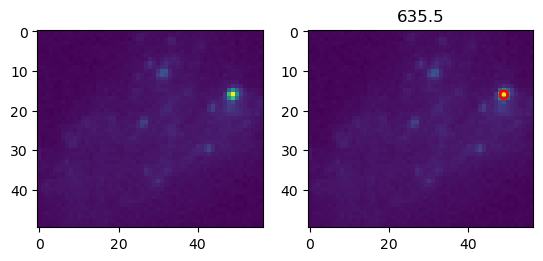

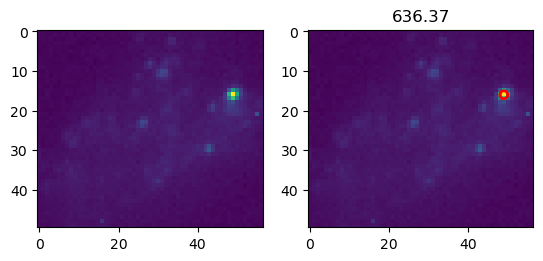

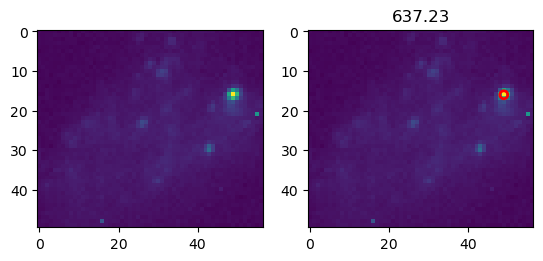

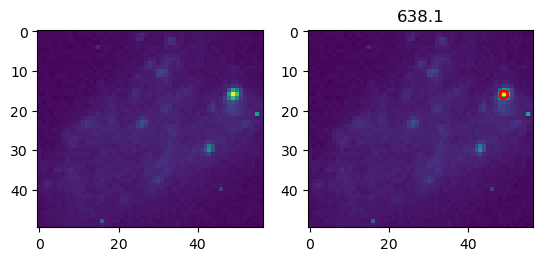

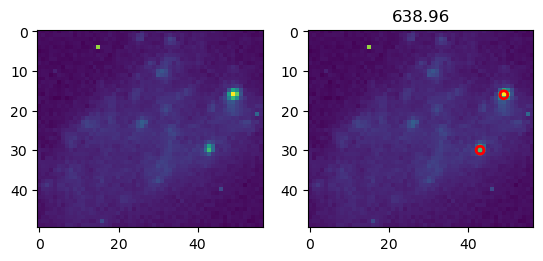

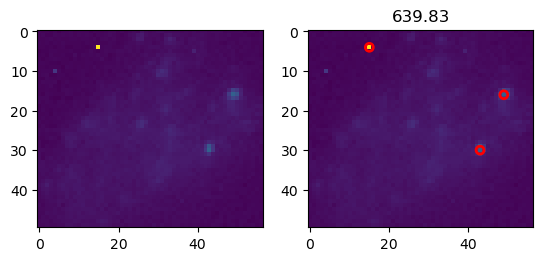

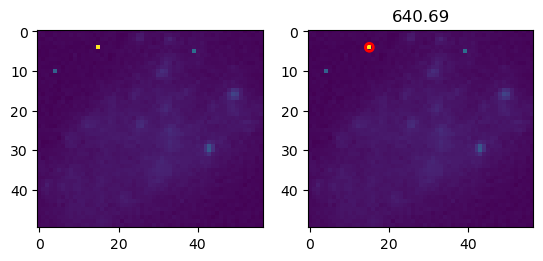

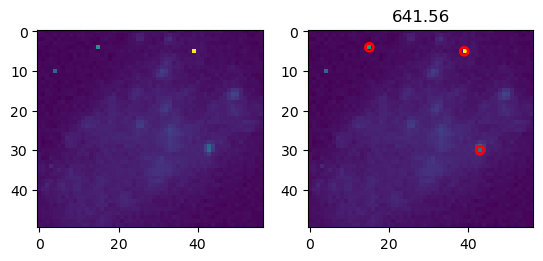

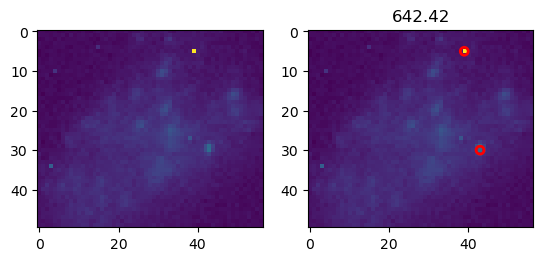

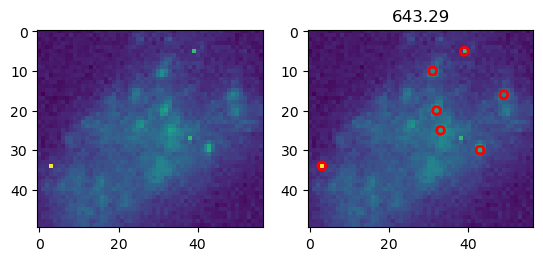

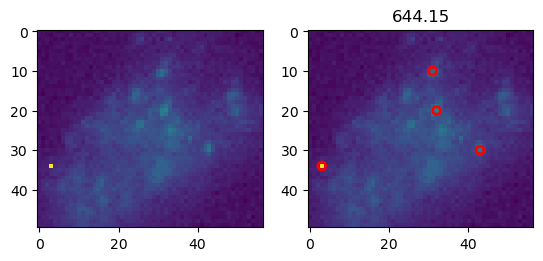

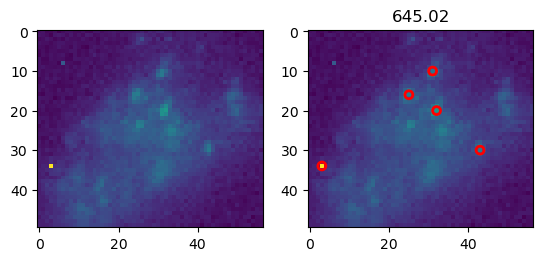

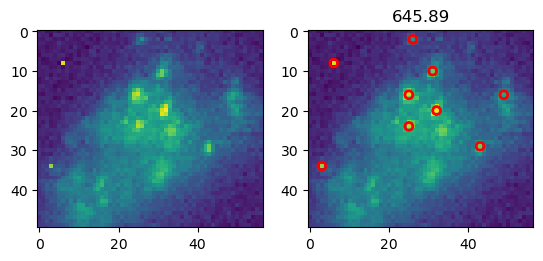

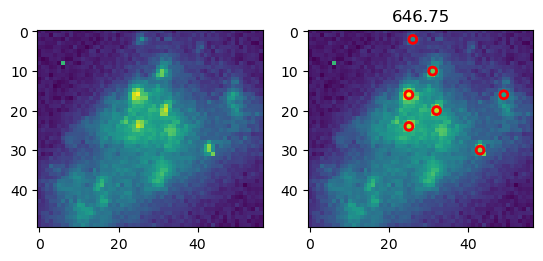

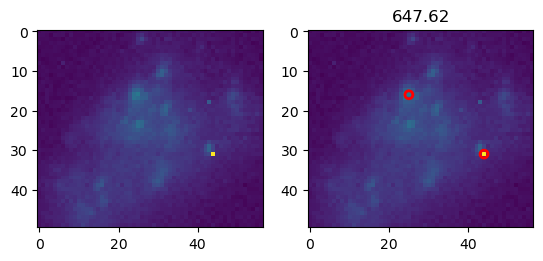

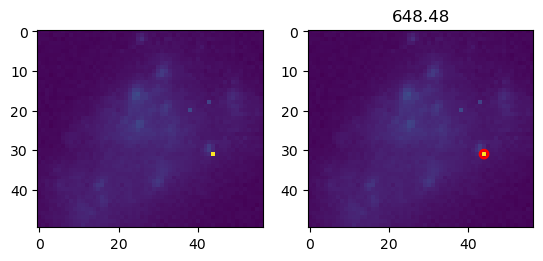

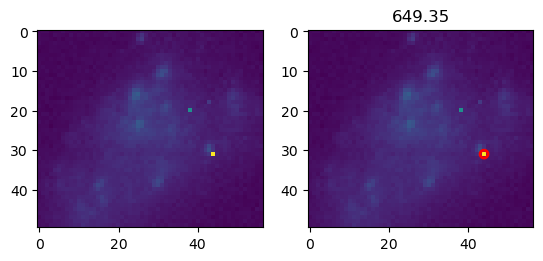

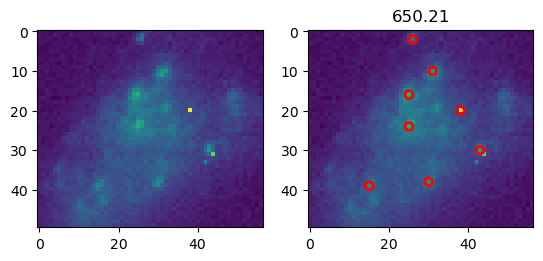

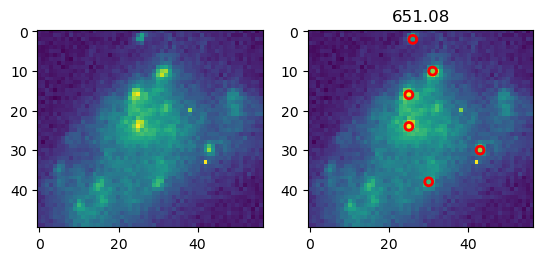

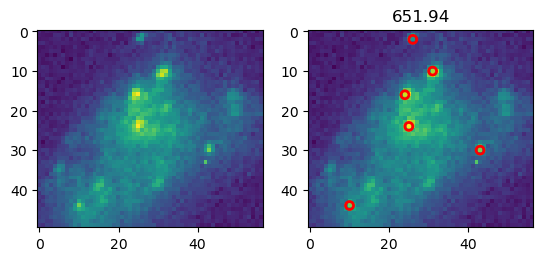

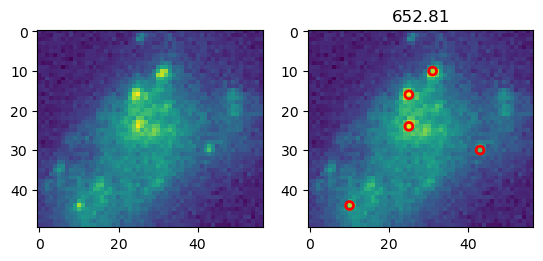

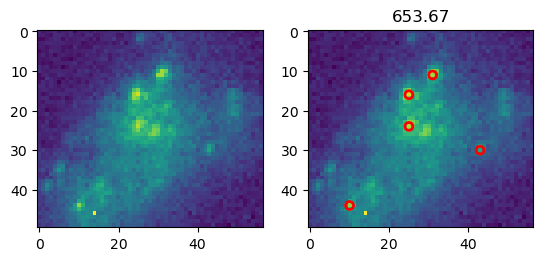

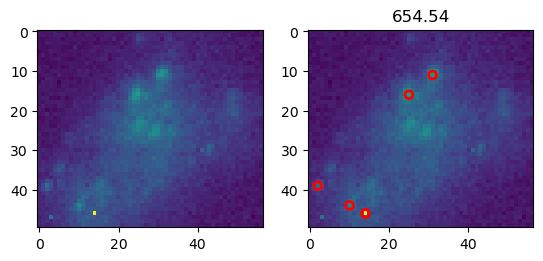

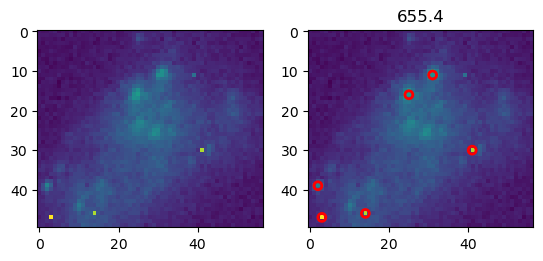

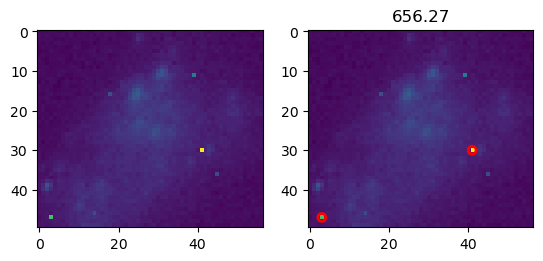

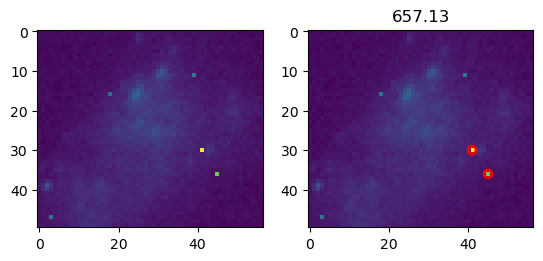

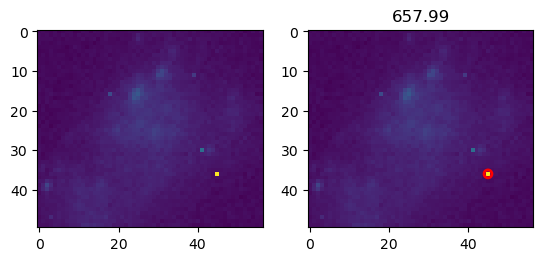

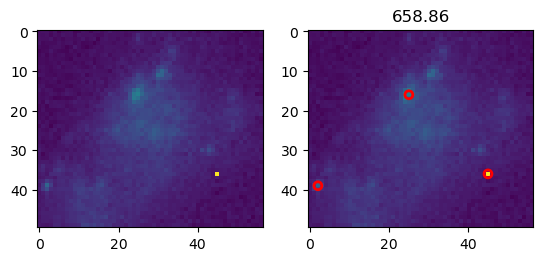

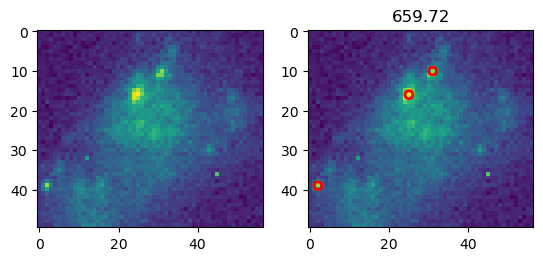

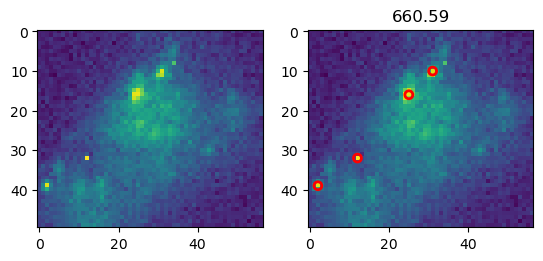

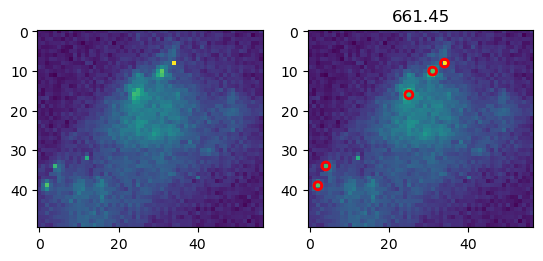

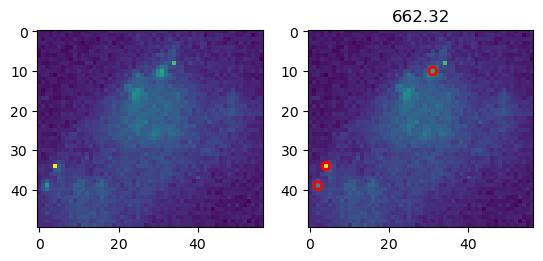

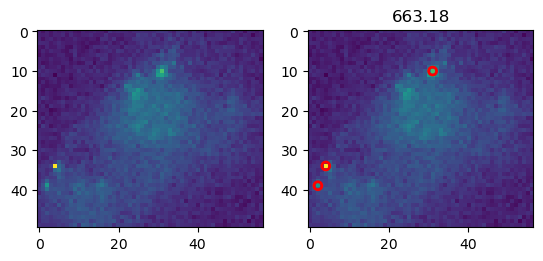

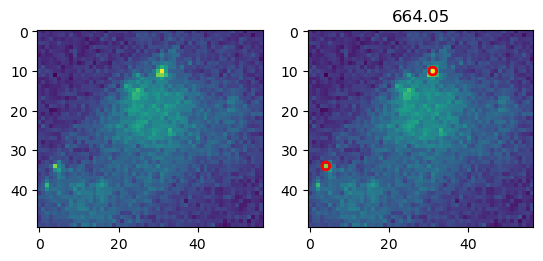

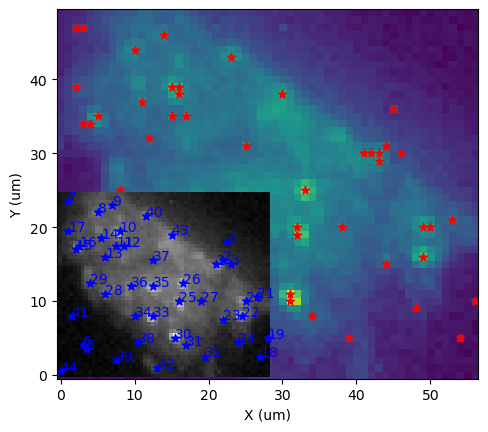

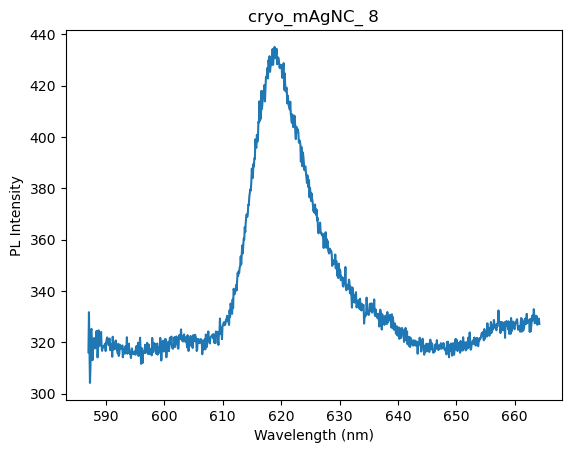

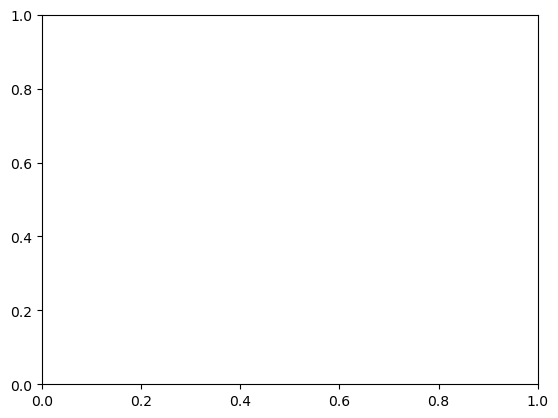

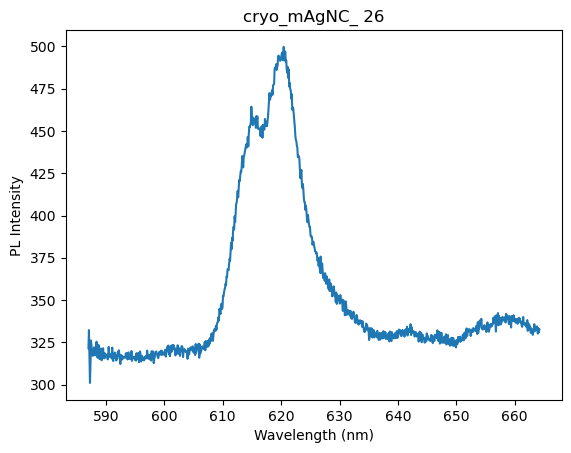

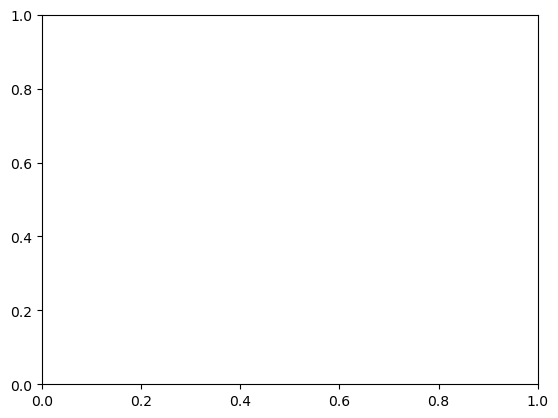

In [66]:
wl,data_ds,x_um,y_um,data = hyperspectral_spatial_image(title,folder,calibration_file,xsteps,ysteps,x_step_size,y_step_size,rel_spec_ind,x_crop,y_crop)
unique_pts,cluster_pred,background_spectra = find_peaks(rel_spec_ind,data)
unique_centroids = label_points(unique_pts,y_um,x_um,rel_spec_ind,title)
silver_plot, silver_wavelength, silver_spectrum = silver_plots(unique_centroids,title,data,wl,background_spectra)
gold_plot, gold_wavelength, gold_spectrum = gold_plots(unique_centroids,title,data,wl,background_spectra)

In [56]:
import matplotlib.pyplot as plt

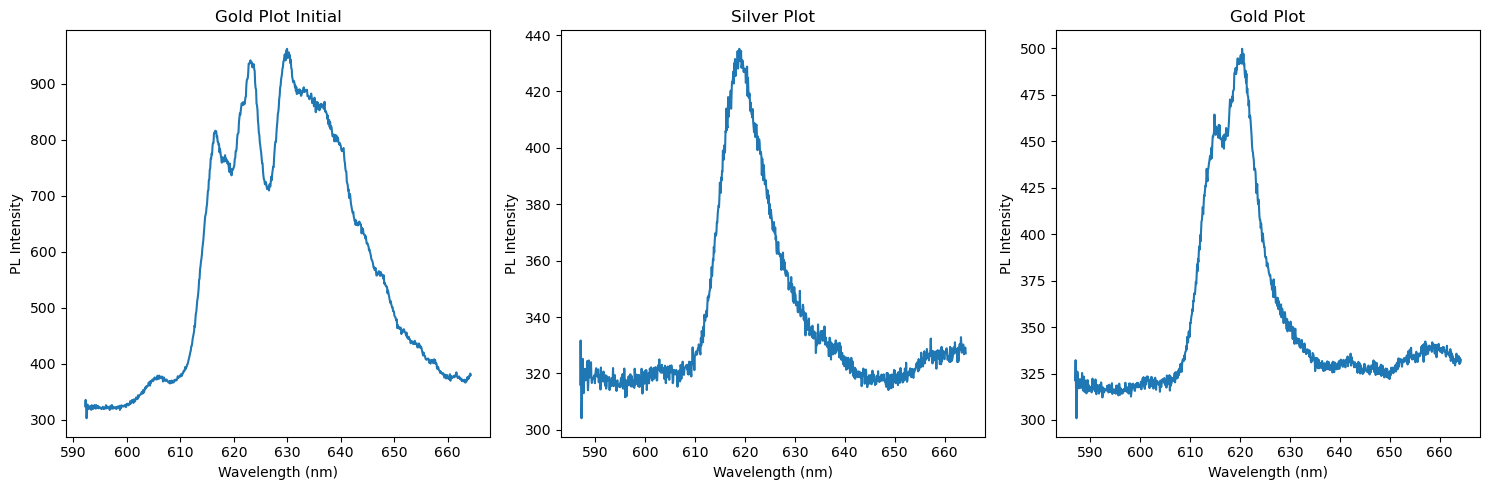

In [71]:
def plot_spectrum(ax, wavelength, spectrum, title):
    ax.plot(wavelength, spectrum)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('PL Intensity')
    ax.set_title(title)
    ax.grid(False)

# Assuming you have data for each plot: gold_plot_initial_spectrum, silver_spectrum, gold_spectrum
# You also need wavelength data for each plot

# Create a figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each spectrum on the corresponding subplot
plot_spectrum(axes[0], gpi_wavelength, gpi_spectrum, 'Gold Plot Initial')
plot_spectrum(axes[1], silver_wavelength, silver_spectrum, 'Silver Plot')
plot_spectrum(axes[2], gold_wavelength, gold_spectrum, 'Gold Plot')

plt.tight_layout()
plt.show()

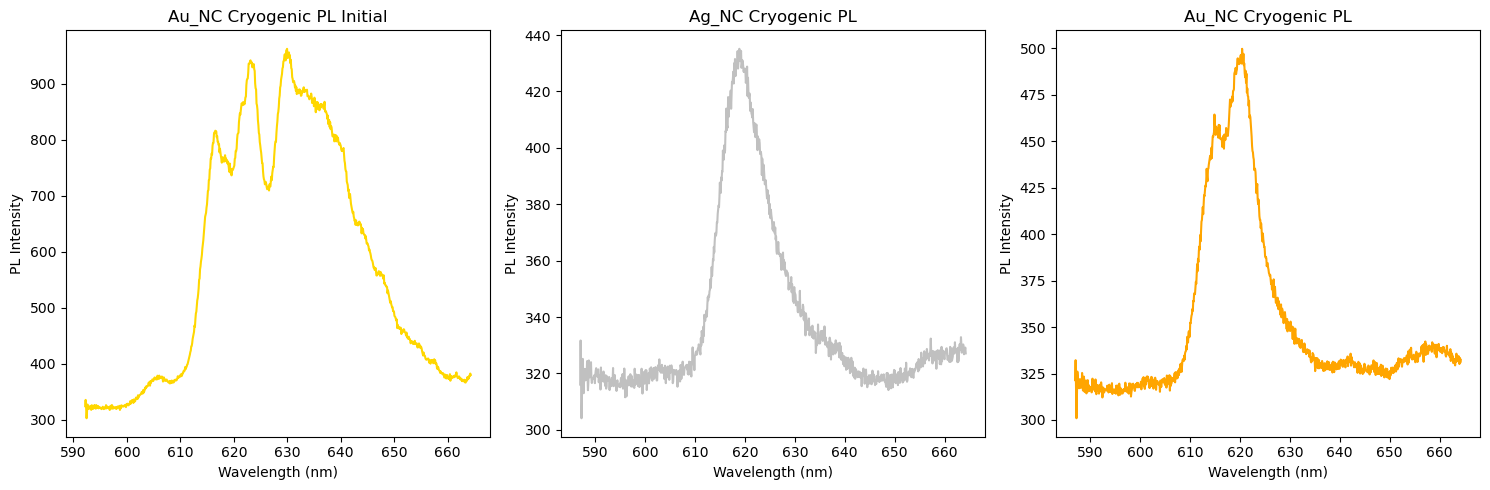

In [84]:
def plot_spectrum(ax, wavelength, spectrum, title, color=None):
    ax.plot(wavelength, spectrum, color=color)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('PL Intensity')
    ax.set_title(title)
    ax.grid(False)

# Assuming you have data for each plot: gold_plot_initial_spectrum, silver_spectrum, gold_spectrum
# You also need wavelength data for each plot

# Create a figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each spectrum on the corresponding subplot
plot_spectrum(axes[0], gpi_wavelength, gpi_spectrum, 'Au_NC Cryogenic PL Initial', color='gold')
plot_spectrum(axes[1], silver_wavelength, silver_spectrum, 'Ag_NC Cryogenic PL', color='silver')
plot_spectrum(axes[2], gold_wavelength, gold_spectrum, 'Au_NC Cryogenic PL', color='orange')

plt.tight_layout()
plt.show()

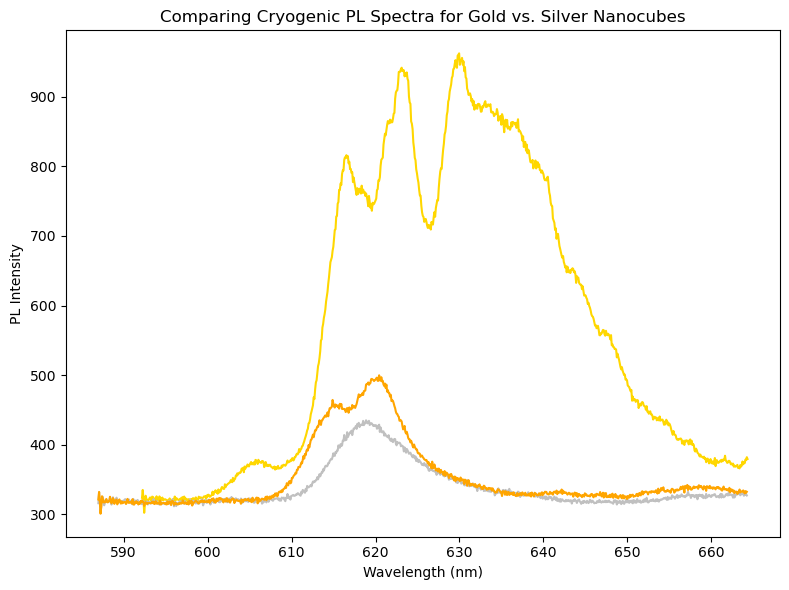

In [83]:
def plot_spectrum(ax, wavelength, spectrum, title, color=None):
    ax.plot(wavelength, spectrum, color=color)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('PL Intensity')
    ax.set_title(title)
    ax.grid(False)

# Assuming you have data for each plot: gold_plot_initial_spectrum, silver_spectrum, gold_spectrum
# You also need wavelength data for each plot

# Create a figure and axes for subplots
fig, ax = plt.subplots(figsize=(8, 6))
# Plot each spectrum on the same subplot
plot_spectrum(ax, gpi_wavelength, gpi_spectrum, 'Gold Plot Initial', color='gold')
plot_spectrum(ax, silver_wavelength, silver_spectrum, 'Silver Plot', color='silver')
plot_spectrum(ax, gold_wavelength, gold_spectrum, 'Comparing Cryogenic PL Spectra for Gold vs. Silver Nanocubes', color='orange')

plt.tight_layout()
plt.show()